!pip install -r requirements.txt

# PART 1 — Data Loading, 3D Grid Construction, Physics-derived Fields, Sequencing

In [ ]:
import os, math, warnings, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.interpolate import griddata
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")
import gc
import time


SEED = 42


import os
import random
import numpy as np
import torch
import torch.nn.functional as F



def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    print(torch.are_deterministic_algorithms_enabled())          # True
    print(torch.is_deterministic_algorithms_warn_only_enabled()) # True
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


set_global_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CSV_PATH = r"D:\Oman_HAB_3D_Dataset - run.csv" # or Oman_HAB_3D_Dataset_bc.csv

# =============================================================================
# OPTIMIZED FEATURE SET — Target = CHL_BC (observation-calibrated)
# =============================================================================
RAW_COLS = [
    # Coordinates
    "Latitude", "Longitude", "Date", "Depth [m]",
    # Physical
    "Temp. [degC]", "Sal.",
    "Current_U [m/s]", "Current_V [m/s]",
    "SSH [m]",
    # Biogeochemical — CHL_BC is target
    "DO [mg/l]",
    "Nitrate [mmol/m3]", "Phosphate [mmol/m3]",
    "Primary_Productivity [mg C/m3/day]",
    # Stratification & Mixing
    "N2",
    "MLD",
    "Sigma0 [kg/m3]",
    "stratification_index",
    "mixed_layer_stability",
    "potential_energy_anomaly",
    "thermocline_strength",
    # Hydrodynamics
    "current_speed",
    "current_shear",
    "current_vorticity",
    "current_divergence",
    # Seasonal forcing
    "monsoon_index",
    "season_sin", "season_cos",
    "day_length",
    # Heatwave
    "surface_RHI_frequency",
    "subsurface_RHI_frequency",
    "depth_of_heatwave",
    # Bathymetry
    "bathymetry_proxy",
    # TARGET (must exist in CSV)
    "chl_bias_corrected",
]

RENAME = {
    "Latitude":"lat","Longitude":"lon","Date":"date","Depth [m]":"depth",
    "Temp. [degC]":"temp","Sal.":"sal",
    "Current_U [m/s]":"u","Current_V [m/s]":"v",
    "SSH [m]":"ssh",
    "DO [mg/l]":"do_",
    "Nitrate [mmol/m3]":"no3","Phosphate [mmol/m3]":"po4",
    "Primary_Productivity [mg C/m3/day]":"pp",
    "N2":"n2",
    "MLD":"mld",
    "Sigma0 [kg/m3]":"sig0",
    "stratification_index":"strat",
    "mixed_layer_stability":"mls",
    "potential_energy_anomaly":"pea",
    "thermocline_strength":"ths",
    "current_speed":"spd",
    "current_shear":"shr",
    "current_vorticity":"vor",
    "current_divergence":"div",
    "monsoon_index":"moni",
    "season_sin":"season_sin","season_cos":"season_cos",
    "day_length":"dl",
    "surface_RHI_frequency":"srhi",
    "subsurface_RHI_frequency":"subrhi",
    "depth_of_heatwave":"hwdepth",
    "bathymetry_proxy":"bath",
    "chl_bias_corrected":"chl_bc",
}

def load_raw_dataframe(path=CSV_PATH):
    raw_cols_needed = list(set(RAW_COLS))  
    
    dtype_map = {c: "float32" for c in raw_cols_needed if c not in ["Date"]}
    
    df = pd.read_csv(path, usecols=lambda c: c.strip() in raw_cols_needed, dtype=dtype_map)
    df.columns = [c.strip() for c in df.columns]
    
    fixed = {}
    for c in df.columns:
        for raw in RAW_COLS:
            if c == raw or c.replace("Âµ","µ") == raw.replace("Âµ","µ"):
                fixed[c] = RENAME[raw]
                break
    df = df.rename(columns=fixed)
    
    needed = list(RENAME.values())
    for col in needed:
        if col not in df.columns:
            warnings.warn(f"Column '{col}' missing from CSV — filling with NaN.")
            df[col] = np.nan
    
    df = df[needed]  
    
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["lat","lon","date","depth"])
    
    numeric_cols = ["temp","sal","u","v","ssh","do_","no3","po4","pp",
                    "n2","mld","sig0","strat","mls","pea","ths","spd","shr",
                    "vor","div","moni","season_sin","season_cos","dl","srhi",
                    "subrhi","hwdepth","bath","chl_bc"]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce", downcast="float")
    
    df["year"] = df["date"].dt.year.astype("int16")
    df["month"] = df["date"].dt.month.astype("int8")
    df["doy"] = df["date"].dt.dayofyear.astype("int16")

    if "chl_bc" in df.columns:
        df["chl_bc"] = df["chl_bc"].clip(lower=0.0)

    return df

class GridConfig:
    def __init__(self, df, n_lat=24, n_lon=24, n_depth=12,
                 seq_len=10, horizons=(1,3,7)):
        self.lat_edges = np.linspace(df["lat"].min(), df["lat"].max(), n_lat+1)
        self.lon_edges = np.linspace(df["lon"].min(), df["lon"].max(), n_lon+1)
        self.lat_centers = (self.lat_edges[:-1]+self.lat_edges[1:])/2
        self.lon_centers = (self.lon_edges[:-1]+self.lon_edges[1:])/2
        self.depth_levels = np.quantile(df["depth"].dropna().unique(),
                                         np.linspace(0,1,n_depth))
        self.depth_levels = np.unique(np.round(self.depth_levels,2))
        self.n_depth = len(self.depth_levels)
        self.n_lat = n_lat
        self.n_lon = n_lon
        self.seq_len = seq_len
        self.horizons = horizons

FEATURE_VARS = ["temp","sal","u","v","ssh","do_","no3","po4","pp","n2","mld",
                "sig0","strat","mls","pea","ths","spd","shr","vor","div",
                "moni","season_sin","season_cos","dl","srhi","subrhi","hwdepth","bath"]
TARGET_VAR = "chl_bc"

def build_3d_grid_for_date(df_day, cfg):
    n_lat, n_lon, n_depth = cfg.n_lat, cfg.n_lon, cfg.n_depth
    # +1 for target channel (chl_bc) which is appended as last channel
    grid = np.zeros((len(FEATURE_VARS) + 1, n_depth, n_lat, n_lon), dtype=np.float32)
    lat_idx = np.clip(np.digitize(df_day["lat"], cfg.lat_edges)-1, 0, n_lat-1)
    lon_idx = np.clip(np.digitize(df_day["lon"], cfg.lon_edges)-1, 0, n_lon-1)
    depth_idx = np.array([np.argmin(np.abs(cfg.depth_levels-d)) for d in df_day["depth"]])
    
    # Features
    for vi, var in enumerate(FEATURE_VARS):
        if var not in df_day.columns:
            continue
        vals = df_day[var].values
        np.add.at(grid[vi], (depth_idx, lat_idx, lon_idx), np.nan_to_num(vals, nan=0.0))
    
    # Target (chl_bc) — last channel
    if TARGET_VAR in df_day.columns:
        vals_target = df_day[TARGET_VAR].values
        np.add.at(grid[len(FEATURE_VARS)], (depth_idx, lat_idx, lon_idx), np.nan_to_num(vals_target, nan=0.0))
    
    counts = np.zeros((n_depth, n_lat, n_lon), dtype=np.float32)
    np.add.at(counts, (depth_idx, lat_idx, lon_idx), 1.0)
    counts[counts==0] = np.nan
    
    for vi in range(len(FEATURE_VARS) + 1):
        grid[vi] = grid[vi] / counts
    
    for vi in range(len(FEATURE_VARS) + 1):
        for dz in range(n_depth):
            layer = grid[vi, dz]
            mask = ~np.isnan(layer)
            if mask.sum() >= 4:
                pts = np.array(np.nonzero(mask)).T
                vals = layer[mask]
                gy, gx = np.mgrid[0:n_lat, 0:n_lon]
                filled = griddata(pts, vals, (gy, gx), method="linear")
                nanmask = np.isnan(filled)
                if nanmask.any():
                    filled_n = griddata(pts, vals, (gy, gx), method="nearest")
                    filled[nanmask] = filled_n[nanmask]
                grid[vi, dz] = filled
            elif mask.sum() > 0:
                grid[vi, dz] = np.nanmean(vals)
            else:
                grid[vi, dz] = 0.0
    return np.nan_to_num(grid, nan=0.0)


def _get_memmap_path(base_path):
    """timestamped """
    if not os.path.exists(base_path):
        return base_path
    try:
        os.remove(base_path)
        return base_path
    except PermissionError:
        ts = time.strftime("%Y%m%d_%H%M%S")
        root, ext = os.path.splitext(base_path)
        alt = f"{root}_{ts}{ext}"
        print(f"[memmap] {base_path} locked → using {alt}")
        return alt


def build_full_spatiotemporal_tensor(df, cfg, cache_path="grid_cache.dat"):
    expected_channels = len(FEATURE_VARS) + 1
    meta_path = cache_path.replace('.dat', '_meta.npz')
    expected_tail = (expected_channels, cfg.n_depth, cfg.n_lat, cfg.n_lon)
    
    # ---------- Check existing cache (validate ALL spatial dims) ----------
    if os.path.exists(cache_path) and os.path.exists(meta_path):
        try:
            z = np.load(meta_path, allow_pickle=True)
            cached_shape = tuple(z["shape"])
            if cached_shape[1:] == expected_tail:
                print(f"[memmap] Loading cache: {os.path.abspath(cache_path)}")
                tensor = np.memmap(cache_path, dtype='float32', mode='r', shape=cached_shape)
                return tensor, pd.to_datetime(z["dates"])
            else:
                print(f"[memmap] Cache SHAPE mismatch: expected {expected_tail}, found {cached_shape[1:]}. Rebuilding...")
                for f in [cache_path, meta_path]:
                    if os.path.exists(f):
                        try:
                            os.remove(f)
                        except PermissionError:
                            ts = time.strftime("%Y%m%d_%H%M%S")
                            base, ext = os.path.splitext(f)
                            stale = f"{base}_stale_{ts}{ext}"
                            os.rename(f, stale)
                            print(f"  Renamed locked file to: {stale}")
        except Exception as e:
            print(f"[WARN] Cache load failed: {e}. Rebuilding...")

    dates = sorted(df["date"].dropna().unique())
    n_dates = len(dates)
    nC, nD, nH, nW = expected_channels, cfg.n_depth, cfg.n_lat, cfg.n_lon
    
    # If locked, use timestamped name
    if os.path.exists(cache_path):
        try:
            os.remove(cache_path)
        except PermissionError:
            ts = time.strftime("%Y%m%d_%H%M%S")
            root, ext = os.path.splitext(cache_path)
            cache_path = f"{root}_{ts}{ext}"
            meta_path = cache_path.replace('.dat', '_meta.npz')
            print(f"[memmap] Cache locked → using {cache_path}")

    print(f"[memmap] Allocating {n_dates}×{nC}×{nD}×{nH}×{nW} → {os.path.abspath(cache_path)}")
    
    tensor = np.memmap(cache_path, dtype='float32', mode='w+', 
                       shape=(n_dates, nC, nD, nH, nW))
    
    for i, d in enumerate(dates):
        df_day = df[df["date"] == d]
        if len(df_day) == 0:
            continue
        tensor[i] = build_3d_grid_for_date(df_day, cfg)
        if i % 100 == 0:
            tensor.flush()
    
    np.savez(meta_path, dates=np.array(dates), shape=tensor.shape)
    tensor.flush()
    
    del tensor
    gc.collect()
    tensor = np.memmap(cache_path, dtype='float32', mode='r', shape=(n_dates, nC, nD, nH, nW))
    print("[memmap] Tensor ready (read-only).")
    return tensor, pd.to_datetime(dates)

def diagnose_vertical_velocity(tensor, feat_idx, cfg, dt_seconds=86400.0):
    u = tensor[:, feat_idx["u"]]   # (T, D, H, W)
    v = tensor[:, feat_idx["v"]]
    
    # Robust: use tensor's actual depth count as ground truth
    n_depth = u.shape[1]
    if n_depth != len(cfg.depth_levels):
        warnings.warn(f"diagnose_vertical_velocity: tensor depth {n_depth} != cfg {len(cfg.depth_levels)}. Using tensor.")
        depth_levels = np.linspace(cfg.depth_levels[0], cfg.depth_levels[-1], n_depth)
    else:
        depth_levels = cfg.depth_levels
    
    dlat = np.gradient(cfg.lat_centers).mean() * 111000.0 if len(cfg.lat_centers) > 1 else 1.0
    dlon = np.gradient(cfg.lon_centers).mean() * 111000.0 * np.cos(np.deg2rad(np.mean(cfg.lat_centers))) if len(cfg.lon_centers) > 1 else 1.0
    
    dudx = np.gradient(u, axis=-1) / dlon
    dvdy = np.gradient(v, axis=-2) / dlat
    div_h = dudx + dvdy
    
    w = np.zeros_like(u)
    for k in range(1, n_depth):
        dz = max(depth_levels[k] - depth_levels[k-1], 1e-3)
        w[:, k] = w[:, k-1] - div_h[:, k-1] * dz
    return w.astype(np.float32)


def diagnose_vertical_diffusivity(tensor, feat_idx, cfg, k_bg=1e-5, k_mix=1e-2):
    mld = tensor[:, feat_idx["mld"], 0]  # (T, H, W) — surface slice
    n2 = tensor[:, feat_idx["n2"]]       # (T, D, H, W)
    
    n_depth = n2.shape[1]
    if n_depth != len(cfg.depth_levels):
        warnings.warn(f"diagnose_vertical_diffusivity: tensor depth {n_depth} != cfg {len(cfg.depth_levels)}. Using tensor.")
        depth_levels = np.linspace(cfg.depth_levels[0], cfg.depth_levels[-1], n_depth)
    else:
        depth_levels = cfg.depth_levels
    
    depth_levels = depth_levels.reshape(1, n_depth, 1, 1)
    above_mld = depth_levels <= mld[:, None, :, :]  # (T, D, H, W)
    n2_safe = np.clip(n2, 1e-8, None)
    k_strat = k_bg + k_mix / (1.0 + n2_safe * 1e3)
    K = np.where(above_mld, k_mix, k_strat)
    return K.astype(np.float32)

# FEAT_IDX maps feature names to channel indices in the tensor
FEAT_IDX = {v: i for i, v in enumerate(FEATURE_VARS)}
TARGET_IDX = len(FEATURE_VARS)  # chl_bc is the last channel
FEAT_IDX["chl_bc"] = TARGET_IDX

def normalize_tensor(tensor, out_path="grid_norm.dat", chunk_size=50):
    T, C, D, H, W = tensor.shape
    n_total = T * D * H * W
    
    # Pass 1: Mean
    mean = np.zeros(C, dtype=np.float64)
    for i in range(0, T, chunk_size):
        chunk = np.array(tensor[i:i+chunk_size])
        mean += chunk.sum(axis=(0, 2, 3, 4))
    mean = mean / n_total
    
    # Pass 2: Std
    var = np.zeros(C, dtype=np.float64)
    for i in range(0, T, chunk_size):
        chunk = np.array(tensor[i:i+chunk_size])
        var += np.sum((chunk - mean.reshape(1, C, 1, 1, 1))**2, axis=(0, 2, 3, 4))
    std = np.sqrt(var / n_total) + 1e-6
    
    # Pass 3: Write normalized tensor (avoid locked files)
    if os.path.exists(out_path):
        try:
            os.remove(out_path)
        except PermissionError:
            ts = time.strftime("%Y%m%d_%H%M%S")
            root, ext = os.path.splitext(out_path)
            out_path = f"{root}_{ts}{ext}"
            print(f"[memmap] Norm file locked → using {out_path}")
    
    print(f"[memmap] Writing normalized → {os.path.abspath(out_path)}")
    norm_tensor = np.memmap(out_path, dtype='float32', mode='w+', shape=(T, C, D, H, W))
    
    for i in range(0, T, chunk_size):
        end = min(i + chunk_size, T)
        chunk = np.array(tensor[i:end])
        norm_tensor[i:end] = (chunk - mean.reshape(1, C, 1, 1, 1)) / std.reshape(1, C, 1, 1, 1)
    
    norm_tensor.flush()
    del norm_tensor
    gc.collect()
    
    norm_tensor = np.memmap(out_path, dtype='float32', mode='r', shape=(T, C, D, H, W))
    print("[memmap] Normalized tensor ready (read-only).")
    return norm_tensor, mean.astype(np.float32), std.astype(np.float32)

class LazySequenceArray:
    def __init__(self, tensor, starts, seq_len):
        self.tensor = tensor
        self.starts = np.asarray(starts)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        if isinstance(idx, (list, np.ndarray, slice)):
            sub_starts = self.starts[idx]
            return LazySequenceArray(self.tensor, sub_starts, self.seq_len)
        s = int(self.starts[idx])
        return self.tensor[s:s+self.seq_len]

    @property
    def shape(self):
        return (len(self.starts), self.seq_len) + tuple(self.tensor.shape[1:])

    def __array__(self, dtype=None):
        out = np.stack([self[i] for i in range(len(self))])
        return out.astype(dtype) if dtype is not None else out


def make_sequences(tensor, dates, cfg, target_idx):
    seq_len = cfg.seq_len
    horizons = cfg.horizons

    starts = []
    Y = {h: [] for h in horizons}
    aux_dates = []

    for t in range(len(tensor) - seq_len - max(horizons) + 1):
        starts.append(t)
        for h in horizons:
            Y[h].append(tensor[t + seq_len + h - 1, target_idx])
        aux_dates.append(dates[t + seq_len - 1])

    for h in horizons:
        Y[h] = np.stack(Y[h]).astype(np.float32)

    # X includes ALL channels: 28 features + 1 lagged target.
    # The target in X is from PAST timesteps (not future), so this is NOT leakage.
    # Using lagged target as a feature is standard practice in autoregressive forecasting.
    X = LazySequenceArray(tensor, np.asarray(starts, dtype=np.int32), seq_len)
    return X, Y, pd.to_datetime(aux_dates)

def leave_one_year_out_split(dates, years_all=None):
    years = pd.to_datetime(dates).year
    uniq = sorted(pd.unique(years))
    for test_year in uniq:
        test_mask = years == test_year
        train_mask = ~test_mask
        yield test_year, train_mask, test_mask

def train_val_test_split_by_time(n, train_frac=0.7, val_frac=0.15):
    idx = np.arange(n)
    n_train = int(n*train_frac)
    n_val = int(n*val_frac)
    return idx[:n_train], idx[n_train:n_train+n_val], idx[n_train+n_val:]

def get_regime_labels(df_or_tensor_dates):
    dates = pd.to_datetime(df_or_tensor_dates)
    month = dates.month
    monsoon = np.isin(month, [6,7,8,9])
    return np.where(monsoon, "monsoon", "inter_monsoon")

print("PART 1 loaded: data pipeline utilities ready.")

# if __name__ == "__main__":
#     df = load_raw_dataframe(CSV_PATH)
#     print("CSV columns after rename:", df.columns.tolist())
#     print("chl_bc present?", "chl_bc" in df.columns)
#     print("chl_bc stats:", df["chl_bc"].describe().to_dict() if "chl_bc" in df.columns else "MISSING")
#     cfg = GridConfig(df)
#     tensor, dates = build_full_spatiotemporal_tensor(df, cfg)
#     tensor_norm, feat_mean, feat_std = normalize_tensor(tensor)
#     w = diagnose_vertical_velocity(tensor, FEAT_IDX, cfg)
#     K = diagnose_vertical_diffusivity(tensor, FEAT_IDX, cfg)
#     # Target index is the last channel (chl_bc)
#     X, Y, seq_dates = make_sequences(tensor_norm, dates, cfg, TARGET_IDX)
#     tr_idx, va_idx, te_idx = train_val_test_split_by_time(len(X))
#     print("Tensor:", tensor.shape, "Sequences:", X.shape)
#     print("Y std (h=1):", Y[1].std())
#     print("Y unique sample:", np.unique(Y[1])[:10])

#     print("Chl raw min/max:", tensor[:, FEAT_IDX["chl_bc"]].min(), tensor[:, FEAT_IDX["chl_bc"]].max())
#     print("Chl raw std:", tensor[:, FEAT_IDX["chl_bc"]].std())
#     print("Temp raw min/max:", tensor[:, FEAT_IDX["temp"]].min(), tensor[:, FEAT_IDX["temp"]].max())
#     print("Y std (h=1):", Y[1].std())

True
True
PART 1 loaded: data pipeline utilities ready.


# PART 2 — Physics Residual (Advection-Diffusion-Reaction) & Dynamic Causal Graph Module

In [ ]:
# ================= PART 2: PHYSICS RESIDUAL + DYNAMIC CAUSAL GRAPH =================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from itertools import combinations

# ---------- 2.1 Finite-difference operators ----------
def grad_x(field, dx):
    kernel = torch.tensor([-1.0, 0.0, 1.0], device=field.device).view(1,1,1,1,3) / (2*dx)
    f = field.unsqueeze(1)
    f = F.pad(f, (1,1,0,0,0,0), mode="replicate")
    return F.conv3d(f, kernel).squeeze(1)

def grad_y(field, dy):
    kernel = torch.tensor([-1.0, 0.0, 1.0], device=field.device).view(1,1,1,3,1) / (2*dy)
    f = field.unsqueeze(1)
    f = F.pad(f, (0,0,1,1,0,0), mode="replicate")
    return F.conv3d(f, kernel).squeeze(1)

def grad_z(field, dz):
    kernel = torch.tensor([-1.0, 0.0, 1.0], device=field.device).view(1,1,3,1,1) / (2*dz)
    f = field.unsqueeze(1)
    f = F.pad(f, (0,0,0,0,1,1), mode="replicate")
    return F.conv3d(f, kernel).squeeze(1)

def laplacian_z_weighted(field, K, dz):
    dCdz = grad_z(field, dz)
    flux = K * dCdz
    return grad_z(flux, dz)

# ---------- 2.2 Michaelis-Menten ----------
def reaction_term(C, no3, temp, mld=None, depth_levels=None, irradiance=None,
                   mu_max=1.2, k_no3=0.5, k_t=15.0, m_loss=0.15,
                   k_par=0.15, use_light=False):
    no3 = torch.clamp(no3, min=0.0)
    nutrient_lim = no3 / (k_no3 + no3 + 1e-6)
    temp_lim = torch.sigmoid((temp - k_t) / 3.0)
    if use_light and irradiance is not None and depth_levels is not None:
        z = depth_levels.view(1,-1,1,1).to(C.device)
        I_z = irradiance * torch.exp(-k_par * z)
        light_lim = I_z / (I_z + 20.0)
    else:
        light_lim = torch.ones_like(C)
    growth = mu_max * nutrient_lim * temp_lim * light_lim * torch.clamp(C, min=0.0)
    loss = m_loss * torch.clamp(C, min=0.0)
    return growth - loss

# ---------- 2.3 PDE residual ----------
def pde_residual(C_seq, u, v, w, K, no3, temp, dt, dx, dy, dz,
                  mld=None, depth_levels=None, irradiance=None, use_light=False):
    dCdt = (C_seq[:,1:] - C_seq[:,:-1]) / dt
    C_mid = 0.5*(C_seq[:,1:] + C_seq[:,:-1])
    residuals = []
    for t in range(C_mid.shape[1]):
        Ct = C_mid[:, t]
        adv_x = u[:, t] * grad_x(Ct, dx)
        adv_y = v[:, t] * grad_y(Ct, dy)
        adv_z = w[:, t] * grad_z(Ct, dz)
        diff = laplacian_z_weighted(Ct, K[:, t], dz)
        R = reaction_term(Ct, no3[:, t], temp[:, t], mld[:, t] if mld is not None else None,
                           depth_levels, irradiance, use_light=use_light)
        res_t = dCdt[:, t] + adv_x + adv_y + adv_z - diff - R
        residuals.append(res_t)
    residual = torch.stack(residuals, dim=1)
    return residual

def pde_residual_loss(C_seq, u, v, w, K, no3, temp, dt=1.0, dx=1.0, dy=1.0, dz=1.0,
                       mld=None, depth_levels=None, irradiance=None, use_light=False):
    res = pde_residual(C_seq, u, v, w, K, no3, temp, dt, dx, dy, dz,
                        mld, depth_levels, irradiance, use_light)
    return (res**2).mean()

# ---------- 2.4 Stoichiometric coupling ----------
def stoichiometric_residual_loss(C_seq, O2_seq, NO3_seq, redfield_O2C=6.625, redfield_NC=0.15,
                                  mask=None):
    dC = C_seq[:,1:] - C_seq[:,:-1]
    dO2 = O2_seq[:,1:] - O2_seq[:,:-1]
    dNO3 = NO3_seq[:,1:] - NO3_seq[:,:-1]
    res_o2 = dO2 - redfield_O2C*dC
    res_no3 = dNO3 + redfield_NC*dC
    res = res_o2**2 + res_no3**2
    if mask is not None:
        res = res * mask
        return res.sum() / (mask.sum() + 1e-6)
    return res.mean()

# ---------- 2.5 Physics projection layer ----------
class PhysicsProjectionLayer(nn.Module):
    def __init__(self, n_iter=5, step_size=0.1, mass_weight=1.0):
        super().__init__()
        self.n_iter = n_iter
        self.step_size = step_size
        self.mass_weight = mass_weight

    def forward(self, C_pred, C_prior_mass=None):
        C = C_pred
        for _ in range(self.n_iter):
            C = F.softplus(C)
            if C_prior_mass is not None:
                cur_mass = C.mean(dim=list(range(1, C.dim())), keepdim=True)
                target_mass = C_prior_mass.reshape(C.shape[0], *([1] * (C.dim() - 1)))
                grad_mass = (cur_mass - target_mass)
                C = C - self.step_size * self.mass_weight * grad_mass
        return F.softplus(C)

# ---------- 2.6 Dynamic causal discovery (CORRECTED: chl_bc included + signed ATE) ----------
# NOW includes chl_bc to show environmental drivers of / relationships with chlorophyll
CAUSAL_VARS = [
    "chl_bc",           # 0  — HAB target
    "temp", "sal", "u", "v", "ssh", "do_", "no3", "po4", "pp",
    "n2", "mld", "sig0", "strat", "mls", "pea", "ths",
    "spd", "shr", "vor", "div", "moni",
    "season_sin", "season_cos", "dl", "srhi", "subrhi", "hwdepth", "bath"
]

def granger_causal_adjacency(regime_series, max_lag=3, p_thresh=0.05):
    from numpy.linalg import lstsq
    names = list(regime_series.keys())
    n = len(names)
    
    clean_series = {}
    for name in names:
        arr = np.asarray(regime_series[name])
        if arr.ndim > 1:
            arr = arr.mean(axis=tuple(range(1, arr.ndim)))
        clean_series[name] = np.asarray(arr).ravel()
    
    lengths = [len(clean_series[nm]) for nm in names]
    T = min(lengths)
    if T <= max_lag + 5:
        z = np.zeros((n, n), dtype=np.float32)
        return z, z.copy()
    
    for nm in clean_series:
        clean_series[nm] = clean_series[nm][:T]
    # ---------- END ROBUSTNESS ----------
    
    adj = np.zeros((n, n), dtype=np.float32)
    adj_sign = np.zeros((n, n), dtype=np.float32)
    
    for i, effect in enumerate(names):
        y = clean_series[effect][max_lag:].ravel()
        self_lags = [clean_series[effect][max_lag-l:T-l].ravel() for l in range(1, max_lag+1)]
        X_self = np.column_stack(self_lags + [np.ones(len(y), dtype=np.float64)])
        
        for j, cause in enumerate(names):
            if i == j:
                continue
            cause_lags = [clean_series[cause][max_lag-l:T-l].ravel() for l in range(1, max_lag+1)]
            X_cause = np.column_stack(cause_lags)
            
            if X_cause.shape[0] != X_self.shape[0]:
                continue
                
            X_full = np.hstack([X_self, X_cause])
            beta_full, *_ = lstsq(X_full, y, rcond=None)
            resid_full = y - X_full @ beta_full
            ss_res_full = np.sum(resid_full**2) + 1e-8
            
            resid_self = y - X_self @ beta_full[:X_self.shape[1]]
            ss_res_self = np.sum(resid_self**2) + 1e-8
            
            delta_r2 = max(0.0, (ss_res_self - ss_res_full) / ss_res_self)
            adj[j, i] = delta_r2
            
            cause_beta = beta_full[-max_lag:] if max_lag > 0 else np.array([0.0])
            avg_effect = float(np.mean(cause_beta)) if len(cause_beta) else 0.0
            adj_sign[j, i] = float(np.sign(avg_effect)) if delta_r2 > 1e-6 else 0.0
    
    # Prune weak edges
    if adj.sum() > 0:
        thresh = np.percentile(adj[adj > 0], 60) if np.any(adj > 0) else 0.0
        mask_weak = adj < thresh
        adj[mask_weak] = 0.0
        adj_sign[mask_weak] = 0.0
    return adj, adj_sign


def compute_regime_causal_graphs(df, causal_vars=CAUSAL_VARS, max_lag=3):
    graphs = {}
    graphs_signed = {}
    dates = pd.to_datetime(df["date"]) if "date" in df.columns else None
    regimes = {
        "monsoon": df["month"].isin([6,7,8,9]) if "month" in df.columns else None,
        "inter_monsoon": ~df["month"].isin([6,7,8,9]) if "month" in df.columns else None,
        "heatwave": df["srhi"] > df["srhi"].quantile(0.9) if "srhi" in df.columns else None,
    }
    for regime_name, mask in regimes.items():
        if mask is None:
            continue
        sub = df[mask]
        if len(sub) < 20:
            z = np.zeros((len(causal_vars), len(causal_vars)), dtype=np.float32)
            graphs[regime_name] = z
            graphs_signed[regime_name] = z.copy()
            continue
        ts = sub.groupby("date")[causal_vars].mean().sort_index()
        series_dict = {c: ts[c].interpolate().bfill().ffill().values for c in causal_vars}
        adj, adj_sign = granger_causal_adjacency(series_dict, max_lag=max_lag)
        graphs[regime_name] = adj
        graphs_signed[regime_name] = adj_sign
    return graphs, graphs_signed

# ---------- 2.7 Graph encoder ----------
class SimpleGCNEncoder(nn.Module):
    def __init__(self, n_nodes, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.n_nodes = n_nodes
        self.node_embed = nn.Parameter(torch.randn(n_nodes, in_dim) * 0.1)
        self.W1 = nn.Linear(in_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, adj):
        if not torch.is_tensor(adj):
            adj = torch.tensor(adj, dtype=torch.float32, device=self.node_embed.device)
        A = adj + torch.eye(self.n_nodes, device=adj.device)
        D = A.sum(dim=1, keepdim=True).clamp(min=1e-6)
        A_norm = A / D
        h = F.relu(self.W1(A_norm @ self.node_embed))
        h = self.W2(A_norm @ h)
        graph_embedding = h.mean(dim=0)
        return h, graph_embedding

def select_active_causal_graph(graphs_dict, current_month, current_srhi_high):
    if current_srhi_high:
        return graphs_dict.get("heatwave")
    if current_month in [6,7,8,9]:
        return graphs_dict.get("monsoon")
    return graphs_dict.get("inter_monsoon")

print("PART 2 loaded: physics residual + causal graph utilities ready.")



PART 2 loaded: physics residual + causal graph utilities ready.


# PART 3 — Physics-Guided Causal Hybrid Architecture (ConvLSTM3D+CBAM+FNO+Event+Causal+Bayesian Heads)

In [3]:
# ================= PART 3: HYBRID PHYSICS-GUIDED CAUSAL ARCHITECTURE =================
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- 3.1 ConvLSTM3D ----------
class ConvLSTM3DCell(nn.Module):
    def __init__(self, in_ch, hidden_ch, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.hidden_ch = hidden_ch
        self.conv = nn.Conv3d(in_ch + hidden_ch, 4*hidden_ch, kernel_size, padding=pad)

    def forward(self, x, state):
        h, c = state
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c_new = f*c + i*g
        h_new = o*torch.tanh(c_new)
        return h_new, c_new

    def init_state(self, batch, spatial_shape, device):
        D,H,W = spatial_shape
        h = torch.zeros(batch, self.hidden_ch, D, H, W, device=device)
        c = torch.zeros(batch, self.hidden_ch, D, H, W, device=device)
        return h, c

class ConvLSTM3D(nn.Module):
    def __init__(self, in_ch, hidden_ch, kernel_size=3):
        super().__init__()
        self.cell = ConvLSTM3DCell(in_ch, hidden_ch, kernel_size)
        self.hidden_ch = hidden_ch

    def forward(self, x_seq):
        B, T, C, D, H, W = x_seq.shape
        h, c = self.cell.init_state(B, (D,H,W), x_seq.device)
        outputs = []
        for t in range(T):
            h, c = self.cell(x_seq[:,t], (h,c))
            outputs.append(h)
        return torch.stack(outputs, dim=1), (h, c)

# ---------- 3.2 CBAM3D ----------
class ChannelAttention3D(nn.Module):
    def __init__(self, ch, ratio=8):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv3d(ch, ch//ratio, 1), nn.ReLU(),
            nn.Conv3d(ch//ratio, ch, 1))

    def forward(self, x):
        avg = F.adaptive_avg_pool3d(x, 1)
        mx = F.adaptive_max_pool3d(x, 1)
        att = torch.sigmoid(self.mlp(avg) + self.mlp(mx))
        return x * att

class SpatialAttention3D(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv3d(2, 1, kernel_size, padding=kernel_size//2)

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        att = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * att

class MultiScaleCBAM3D(nn.Module):
    def __init__(self, ch, scales=(1,2,4)):
        super().__init__()
        self.scales = scales
        self.ca = nn.ModuleList([ChannelAttention3D(ch) for _ in scales])
        self.sa = nn.ModuleList([SpatialAttention3D() for _ in scales])
        self.fuse = nn.Conv3d(ch*len(scales), ch, 1)

    def forward(self, x):
        outs = []
        for s, ca, sa in zip(self.scales, self.ca, self.sa):
            if s > 1:
                xs = F.avg_pool3d(x, kernel_size=(1,s,s), stride=(1,s,s))
            else:
                xs = x
            xs = ca(xs); xs = sa(xs)
            if s > 1:
                xs = F.interpolate(xs, size=x.shape[2:], mode="trilinear", align_corners=False)
            outs.append(xs)
        return self.fuse(torch.cat(outs, dim=1))

# ---------- 3.3 FNO ----------
class SpectralConv3d(nn.Module):
    def __init__(self, in_ch, out_ch, modes_d, modes_h, modes_w):
        super().__init__()
        self.in_ch, self.out_ch = in_ch, out_ch
        self.modes_d, self.modes_h, self.modes_w = modes_d, modes_h, modes_w
        scale = 1.0 / (in_ch * out_ch)
        self.weight = nn.Parameter(
            scale * torch.rand(in_ch, out_ch, modes_d, modes_h, modes_w, dtype=torch.cfloat)
        )

    def compl_mul(self, inp, weights):
        return torch.einsum("bixyz,ioxyz->boxyz", inp, weights)

    def forward(self, x):
        B, C, D, H, W = x.shape
        orig_dtype = x.dtype
        x32 = x.float()
        x_ft = torch.fft.rfftn(x32, dim=(-3, -2, -1))
        out_ft = torch.zeros(
            B, self.out_ch, D, H, W // 2 + 1,
            dtype=torch.cfloat, device=x.device
        )
        md = min(self.modes_d, D)
        mh = min(self.modes_h, H)
        mw = min(self.modes_w, W // 2 + 1)
        out_ft[:, :, :md, :mh, :mw] = self.compl_mul(
            x_ft[:, :, :md, :mh, :mw],
            self.weight[:, :, :md, :mh, :mw]
        )
        x_out = torch.fft.irfftn(out_ft, s=(D, H, W), dim=(-3, -2, -1))
        return x_out.to(orig_dtype)

class FNOResidualBlock3D(nn.Module):
    def __init__(self, ch, modes=(4,8,8)):
        super().__init__()
        self.spec = SpectralConv3d(ch, ch, *modes)
        self.local = nn.Conv3d(ch, ch, 1)
        self.norm = nn.GroupNorm(min(8,ch), ch)

    def forward(self, x):
        y = self.spec(x) + self.local(x)
        return self.norm(F.gelu(y) + x)

# ---------- 3.4 Regime Attention ----------
class RegimeAttention(nn.Module):
    def __init__(self, ch, n_depth, surf_frac=0.25, dcm_frac=0.35):
        super().__init__()
        self.n_depth = n_depth
        self.n_surf = max(1, int(n_depth*surf_frac))
        self.n_dcm = max(1, int(n_depth*dcm_frac))
        self.attn_surf = nn.MultiheadAttention(ch, num_heads=4, batch_first=True)
        self.attn_thermo = nn.MultiheadAttention(ch, num_heads=4, batch_first=True)
        self.attn_dcm = nn.MultiheadAttention(ch, num_heads=4, batch_first=True)
        self.fuse = nn.Conv3d(ch, ch, 1)

    def _apply_attn(self, x_slice, attn):
        B, C, d, H, W = x_slice.shape
        tok = x_slice.permute(0,2,3,4,1).reshape(B, d*H*W, C)
        out, _ = attn(tok, tok, tok)
        return out.reshape(B, d, H, W, C).permute(0,4,1,2,3)

    def forward(self, x):
        D = x.shape[2]
        s = self.n_surf; e_dcm = D - self.n_dcm
        surf = x[:, :, :s]
        thermo = x[:, :, s:e_dcm]
        dcm = x[:, :, e_dcm:]
        surf_o = self._apply_attn(surf, self.attn_surf) if surf.shape[2]>0 else surf
        thermo_o = self._apply_attn(thermo, self.attn_thermo) if thermo.shape[2]>0 else thermo
        dcm_o = self._apply_attn(dcm, self.attn_dcm) if dcm.shape[2]>0 else dcm
        out = torch.cat([surf_o, thermo_o, dcm_o], dim=2)
        return self.fuse(out) + x

# ---------- 3.5 Event Conditioning ----------
class EventConditioningFiLM(nn.Module):
    def __init__(self, event_dim, ch):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(event_dim, ch*2), nn.ReLU(), nn.Linear(ch*2, ch*2))

    def forward(self, x, event_vec):
        gamma_beta = self.mlp(event_vec)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)
        gamma = gamma.view(*gamma.shape, 1,1,1)
        beta = beta.view(*beta.shape, 1,1,1)
        return x * (1+gamma) + beta

def compute_event_vector(x_last_frame, feat_idx, prev_frame=None):
    hw = x_last_frame[:, feat_idx["hwdepth"]].mean(dim=(1, 2, 3))
    n2 = x_last_frame[:, feat_idx["n2"]]
    n2_collapse = n2.std(dim=(1, 2, 3))
    if prev_frame is not None:
        no3_pulse = (x_last_frame[:, feat_idx["no3"]] - prev_frame[:, feat_idx["no3"]]).mean(dim=(1, 2, 3))
    else:
        no3_pulse = torch.zeros_like(n2_collapse)
    return torch.stack([hw, n2_collapse, no3_pulse], dim=-1)

# ---------- 3.6 Causal Graph Conditioning ----------
class CausalGraphFiLM(nn.Module):
    def __init__(self, graph_dim, ch):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(graph_dim, ch), nn.ReLU(), nn.Linear(ch, ch*2))

    def forward(self, x, graph_embed):
        graph_embed = graph_embed.unsqueeze(0).expand(x.shape[0], -1)
        gamma_beta = self.mlp(graph_embed)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)
        gamma = gamma.view(*gamma.shape, 1,1,1)
        beta = beta.view(*beta.shape, 1,1,1)
        return x * (1+gamma) + beta

# ---------- 3.7 Probabilistic Head ----------
class ProbabilisticHead(nn.Module):
    def __init__(self, ch, dropout=0.15):
        super().__init__()
        self.drop = nn.Dropout3d(dropout)
        self.mean_head = nn.Conv3d(ch, 1, 1)
        self.logvar_head = nn.Conv3d(ch, 1, 1)
        self.hab_prob_head = nn.Conv3d(ch, 1, 1)
        # Initialize logvar bias to moderate uncertainty (logvar ≈ 0 => std ≈ 1)
        nn.init.zeros_(self.logvar_head.bias)

    def forward(self, x):
        x = self.drop(x)
        mean = self.mean_head(x)
        # Clamp logvar to prevent collapse, min std ≈ 0.018 (logvar >= -4.0)
        logvar = self.logvar_head(x).clamp(-4.0, 4.0)
        hab_logits = self.hab_prob_head(x)
        return mean, logvar, hab_logits

# ---------- 3.8 Full hybrid model ----------
class PhysicsGuidedCausalHybridModel(nn.Module):
    def __init__(self, in_ch, hidden_ch=32, n_depth=12, event_dim=3, graph_dim=16,
                 fno_modes=(4,8,8), use_fno=True, use_causal=True, use_event=True,
                 use_regime_attn=True, mc_dropout=0.15):
        super().__init__()
        self.use_fno = use_fno
        self.use_causal = use_causal
        self.use_event = use_event
        self.use_regime_attn = use_regime_attn

        self.convlstm = ConvLSTM3D(in_ch, hidden_ch)
        self.cbam = MultiScaleCBAM3D(hidden_ch)
        if use_fno:
            self.fno = FNOResidualBlock3D(hidden_ch, modes=fno_modes)
        if use_regime_attn:
            self.regime_attn = RegimeAttention(hidden_ch, n_depth)
        if use_event:
            self.event_film = EventConditioningFiLM(event_dim, hidden_ch)
        if use_causal:
            self.causal_film = CausalGraphFiLM(graph_dim, hidden_ch)
        self.proj = nn.Conv3d(hidden_ch, hidden_ch, 3, padding=1)
        self.head = ProbabilisticHead(hidden_ch, dropout=mc_dropout)
        self.physics_proj = PhysicsProjectionLayer(n_iter=3, step_size=0.05, mass_weight=0.1)
        self.physics_enabled = False
        self.register_buffer("chl_mean", torch.tensor(0.0))
        self.register_buffer("chl_std", torch.tensor(1.0))
        self.chl_idx = None

    def configure_physics(self, chl_mean, chl_std, chl_idx, enabled=True):
        self.chl_mean.copy_(torch.as_tensor(chl_mean, dtype=torch.float32, device=self.chl_mean.device))
        self.chl_std.copy_(torch.as_tensor(chl_std, dtype=torch.float32, device=self.chl_std.device))
        self.chl_idx = int(chl_idx)
        self.physics_enabled = bool(enabled)

    def forward(self, x_seq, event_vec=None, graph_embed=None):
        h_seq, (h_last, c_last) = self.convlstm(x_seq)
        h = h_last
        h = self.cbam(h)
        if self.use_fno:
            h = self.fno(h)
        if self.use_regime_attn:
            h = self.regime_attn(h)
        if self.use_event and event_vec is not None:
            h = self.event_film(h, event_vec)
        if self.use_causal and graph_embed is not None:
            h = self.causal_film(h, graph_embed)
        h = F.gelu(self.proj(h))
        mean, logvar, hab_logits = self.head(h)

        # Physics projection disabled in forward — too unstable.
        # PDE residual loss is already applied separately in train_model.
        hab_prob = torch.sigmoid(hab_logits)
        return mean.squeeze(1), logvar.squeeze(1), hab_logits.squeeze(1)

    def mc_predict(self, x_seq, event_vec=None, graph_embed=None, n_samples=20):
        self.train()
        preds = []
        rng_state = torch.get_rng_state()
        try:
            torch.manual_seed(42)
            with torch.no_grad():
                for _ in range(n_samples):
                    mean, logvar, hab_prob = self.forward(x_seq, event_vec, graph_embed)
                    preds.append(mean.unsqueeze(0))
        finally:
            torch.set_rng_state(rng_state)  
        
        preds = torch.cat(preds, dim=0)
        mc_mean = preds.mean(dim=0)
        mc_std = preds.std(dim=0) + torch.exp(0.5 * logvar)
        return mc_mean, mc_std

# ---------- 3.9 Ablation factory ----------
def build_ablation_model(variant, in_ch, hidden_ch=32, n_depth=12):
    if variant == "a_baseline":
        return PhysicsGuidedCausalHybridModel(in_ch, hidden_ch, n_depth,
                use_fno=False, use_causal=False, use_event=False, use_regime_attn=True)
    if variant == "b_physics":
        return PhysicsGuidedCausalHybridModel(in_ch, hidden_ch, n_depth,
                use_fno=False, use_causal=False, use_event=False, use_regime_attn=True)
    if variant == "c_fno":
        return PhysicsGuidedCausalHybridModel(in_ch, hidden_ch, n_depth,
                use_fno=True, use_causal=False, use_event=False, use_regime_attn=True)
    if variant == "d_full":
        return PhysicsGuidedCausalHybridModel(in_ch, hidden_ch, n_depth,
                use_fno=True, use_causal=True, use_event=True, use_regime_attn=True)
    raise ValueError(variant)

# ---------- 3.10 Transformer baseline ----------
class TransformerBaseline(nn.Module):
    def __init__(self, in_ch, n_depth, n_lat, n_lon, d_model=64, nhead=4, n_layers=2):
        super().__init__()
        self.in_proj = nn.Linear(in_ch, d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.out_proj = nn.Linear(d_model, 1)
        self.n_depth, self.n_lat, self.n_lon = n_depth, n_lat, n_lon

    def forward(self, x_seq):
        B, T, C, D, H, W = x_seq.shape
        x = x_seq.mean(dim=(3,4,5))
        x = self.in_proj(x)
        x = self.encoder(x)
        out = self.out_proj(x[:, -1])
        return out.squeeze(-1)

print("PART 3 loaded: hybrid physics-guided causal architecture ready.")

PART 3 loaded: hybrid physics-guided causal architecture ready.


# PART 4 — Training, Optuna Hyperparameter Optimization, Evaluation, Ablation, Cross-Regime/LOYO, Process Attribution

In [ ]:
# ================= PART 4: TRAINING, OPTUNA HPO, EVALUATION, ABLATION =================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
try:
    import optuna
except ImportError:
    optuna = None

# ---------- 4.1 Dataset ----------
class HABSequenceDataset(Dataset):
    def __init__(self, X, Y_dict, u_idx, v_idx, w_field, K_field, no3_idx, temp_idx,
                 mld_idx, event_extra=None):
        self.X = X
        self.Y_dict = Y_dict
        self.u_idx, self.v_idx = u_idx, v_idx
        self.w_field, self.K_field = w_field, K_field
        self.no3_idx, self.temp_idx, self.mld_idx = no3_idx, temp_idx, mld_idx

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        x = torch.tensor(self.X[i], dtype=torch.float32)
        y = {h: torch.tensor(self.Y_dict[h][i], dtype=torch.float32) for h in self.Y_dict}
        sequence_start = int(self.X.starts[i]) if hasattr(self.X, "starts") else i
        return x, y, sequence_start

def collate_batch(batch):
    xs = torch.stack([b[0] for b in batch])
    idxs = [b[2] for b in batch]
    y_out = {}
    for h in batch[0][1].keys():
        y_out[h] = torch.stack([b[1][h] for b in batch])
    return xs, y_out, idxs

def build_physics_batch(starts, raw_tensor, w_field, K_field, cfg_model, device):
    t = np.asarray(starts, dtype=int) + cfg_model.seq_len - 1
    state = torch.as_tensor(raw_tensor[t], dtype=torch.float32, device=device)
    w = torch.as_tensor(w_field[t], dtype=torch.float32, device=device)
    K = torch.as_tensor(K_field[t], dtype=torch.float32, device=device)
    sec_per_day = 86400.0
    dx = float(np.mean(np.diff(cfg_model.lon_centers)) * 111000.0 * np.cos(np.deg2rad(np.mean(cfg_model.lat_centers))))
    dy = float(np.mean(np.diff(cfg_model.lat_centers)) * 111000.0)
    dz = float(max(np.mean(np.diff(cfg_model.depth_levels)), 1e-3))
    return {
        "chl_last": state[:, FEAT_IDX["chl_bc"]],
        "u": state[:, FEAT_IDX["u"]].unsqueeze(1) * sec_per_day,
        "v": state[:, FEAT_IDX["v"]].unsqueeze(1) * sec_per_day,
        "w": w.unsqueeze(1) * sec_per_day,
        "K": K.unsqueeze(1) * sec_per_day,
        "no3": state[:, FEAT_IDX["no3"]].unsqueeze(1),
        "temp": state[:, FEAT_IDX["temp"]].unsqueeze(1),
        "mld": state[:, FEAT_IDX["mld"]].unsqueeze(1),
        "dx": abs(dx), "dy": abs(dy), "dz": dz,
    }

def physics_loss_from_prediction(mean_norm, starts, physics_data, cfg_model, device,
                                   normalize=True, eps=1e-6):
    if physics_data is None:
        return None
    p = build_physics_batch(starts, physics_data["raw_tensor"], physics_data["w"],
                             physics_data["K"], cfg_model, device)
    chl_mean = torch.as_tensor(physics_data["chl_mean"], dtype=mean_norm.dtype, device=device)
    chl_std  = torch.as_tensor(physics_data["chl_std"],  dtype=mean_norm.dtype, device=device)
    c_next = mean_norm * chl_std + chl_mean
    c_seq = torch.stack([p["chl_last"], c_next], dim=1)

    finite_ok = (
        torch.isfinite(c_seq).all() and torch.isfinite(p["u"]).all() and
        torch.isfinite(p["v"]).all() and torch.isfinite(p["w"]).all() and
        torch.isfinite(p["K"]).all() and torch.isfinite(p["no3"]).all() and
        torch.isfinite(p["temp"]).all()
    )
    if not finite_ok:
        return torch.zeros((), device=device, dtype=mean_norm.dtype)

    if not normalize:
        return pde_residual_loss(c_seq, p["u"], p["v"], p["w"], p["K"],
                                  p["no3"], p["temp"], dt=1.0,
                                  dx=p["dx"], dy=p["dy"], dz=p["dz"],
                                  mld=p["mld"])

    dt, dx, dy, dz = 1.0, p["dx"], p["dy"], p["dz"]
    dCdt   = (c_seq[:, 1:] - c_seq[:, :-1]) / dt
    C_mid  = 0.5 * (c_seq[:, 1:] + c_seq[:, :-1])
    Ct     = C_mid[:, 0]
    adv_x = p["u"][:, 0] * grad_x(Ct, dx)
    adv_y = p["v"][:, 0] * grad_y(Ct, dy)
    adv_z = p["w"][:, 0] * grad_z(Ct, dz)
    advection = adv_x + adv_y + adv_z
    diffusion = laplacian_z_weighted(Ct, p["K"][:, 0], dz)
    reaction = reaction_term(Ct, p["no3"][:, 0], p["temp"][:, 0], p["mld"][:, 0], depth_levels=None)

    def _term_norm(t):
        scale = t.detach().std().clamp_min(eps)
        return t / scale

    residual_norm = (
        _term_norm(dCdt[:, 0]) + _term_norm(advection)
        - _term_norm(diffusion) - _term_norm(reaction)
    )
    loss = (residual_norm ** 2).mean()
    if not torch.isfinite(loss):
        return torch.zeros((), device=device, dtype=mean_norm.dtype)
    loss = torch.clamp(loss, max=100.0)
    return loss


# ---------- 4.2 Loss function ----------
def gaussian_nll(mean, logvar, target):
    inv_var = torch.exp(-logvar)
    return (0.5*inv_var*(target-mean)**2 + 0.5*logvar).mean()

def hab_bce_loss(hab_logits, target_chl, threshold=5.0):
    label = (target_chl > threshold).float()
    return F.binary_cross_entropy_with_logits(hab_logits, label)

def composite_loss(mean, logvar, hab_logits, target, physics_res_loss=None,
                   stoich_loss=None, w_data=1.0, w_physics=0.1, w_stoich=0.05,
                   w_hab=0.2, hab_threshold=5.0):
    # Always MSE — NLL causes collapse to trivial minimum (predicting mean with tiny variance)
    data_loss = F.mse_loss(mean, target)
    hab_loss = hab_bce_loss(hab_logits, target, threshold=hab_threshold)
    total = w_data * data_loss + w_hab * hab_loss
    if physics_res_loss is not None and torch.isfinite(physics_res_loss):
        # Adaptive scaling: dampen physics loss if it dominates data loss
        scale = 1.0
        with torch.no_grad():
            data_val = data_loss.detach()
            phys_val = physics_res_loss.detach()
            if phys_val > 10.0 * data_val and data_val > 0:
                scale = (10.0 * data_val / phys_val).clamp_min(0.01)
        total = total + w_physics * scale * physics_res_loss
    if stoich_loss is not None and torch.isfinite(stoich_loss):
        total = total + w_stoich * stoich_loss
    # Correlation-based R² for monitoring (safe when target is raw and pred is normalized)
    with torch.no_grad():
        pred_flat = mean.detach().reshape(-1)
        targ_flat = target.detach().reshape(-1)
        valid = torch.isfinite(pred_flat) & torch.isfinite(targ_flat)
        if valid.sum() > 10:
            p = pred_flat[valid]
            t = targ_flat[valid]
            r_num = ((p - p.mean()) * (t - t.mean())).sum()
            r_den = torch.sqrt(((p - p.mean())**2).sum() * ((t - t.mean())**2).sum()) + 1e-8
            r2 = (r_num / r_den).item() ** 2
        else:
            r2 = float('nan')
    return total, {
        "data": data_loss.item(),
        "hab": hab_loss.item(),
        "physics": float(physics_res_loss) if physics_res_loss is not None else 0.0,
        "r2": r2,
    }

# ---------- 4.3 Training loop ----------
def train_model(
    model,
    train_loader,
    val_loader,
    cfg_model,
    epochs=30,
    lr=1e-3,
    w_physics=0.1,
    w_stoich=0.05,
    device=DEVICE,
    use_physics=True,
    event_provider=None,
    graph_embed=None,
    physics_data=None,
    patience=6,
    verbose=True,
    benchmark_first=False,
    stage_label="train",
):
    model.to(device)
    amp_enabled = device.type == "cuda"

    if benchmark_first:
        benchmark_step_cost(model, train_loader, cfg_model, device, use_physics, physics_data)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)

    if event_provider is None:
        def event_provider(x_seq):
            prev = x_seq[:, -2] if x_seq.shape[1] > 1 else None
            return compute_event_vector(x_seq[:, -1], FEAT_IDX, prev)

    g_embed = graph_embed.to(device) if graph_embed is not None else None
    horizon = min(cfg_model.horizons)

    history = {"train_loss": [], "val_loss": [], "train_data_loss": [],
               "train_phys_loss": [], "val_data_loss": [], "val_phys_loss": []}

    best_val_loss, best_model_state, patience_counter = float("inf"), None, 0

    def _hab_threshold():
        if physics_data is None:
            return 5.0
        return (5.0 - physics_data["chl_mean"]) / physics_data["chl_std"]

    def _run_batch(x, y, idxs, training):
        x = x.to(device)
        target = y[horizon].to(device)
        event_vec = event_provider(x) if event_provider is not None else None

        with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=amp_enabled):
            mean, logvar, hab_logits = model(x, event_vec, g_embed)
            data_target = target
            d_loss, loss_dict = composite_loss(mean, logvar, hab_logits,
                                        data_target, hab_threshold=_hab_threshold())

        p_loss = torch.zeros((), device=device)
        if use_physics and physics_data is not None:
            with torch.autocast(device_type=device.type, enabled=False):
                phys_res = physics_loss_from_prediction(mean.float(), idxs, physics_data, cfg_model, device)
            if phys_res is not None:
                p_loss = phys_res

        loss = d_loss + w_physics * p_loss

        if training:
            if torch.isfinite(loss) and loss.detach().item() < 1e9:
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                opt.step()
            else:
                print(f"[WARN] Skipping batch: non-finite loss")

        return loss.item(), d_loss.item(), float(p_loss.item()), loss_dict

    # =====================================================================
    # EPOCH LOOP — note the return is OUTSIDE this block
    # =====================================================================
    for epoch in range(1, epochs + 1):
        model.train()
        tr_loss = tr_data = tr_phys = tr_r2 = 0.0
        n_tr = 0
        for x, y, idxs in train_loader:
            l, d, p, ld = _run_batch(x, y, idxs, training=True)
            tr_loss += l; tr_data += d; tr_phys += p; tr_r2 += ld.get("r2", 0); n_tr += 1
        avg_tr_loss = tr_loss / max(n_tr, 1)
        avg_tr_data = tr_data / max(n_tr, 1)
        avg_tr_phys = tr_phys / max(n_tr, 1)
        avg_tr_r2 = tr_r2 / max(n_tr, 1)

        model.eval()
        va_loss = va_data = va_phys = va_r2 = 0.0
        n_va = 0
        with torch.no_grad():
            for x, y, idxs in val_loader:
                l, d, p, ld = _run_batch(x, y, idxs, training=False)
                va_loss += l; va_data += d; va_phys += p; va_r2 += ld.get("r2", 0); n_va += 1
        avg_va_loss = va_loss / max(n_va, 1)
        avg_va_data = va_data / max(n_va, 1)
        avg_va_phys = va_phys / max(n_va, 1)
        avg_va_r2 = va_r2 / max(n_va, 1)

        scheduler.step(avg_va_loss)

        history["train_loss"].append(avg_tr_loss)
        history["val_loss"].append(avg_va_loss)
        history["train_data_loss"].append(avg_tr_data)
        history["val_data_loss"].append(avg_va_data)
        history["train_phys_loss"].append(avg_tr_phys)
        history["val_phys_loss"].append(avg_va_phys)

        if verbose:
            print(f"[{stage_label}] epoch {epoch:02d}/{epochs:02d} "
                    f"train={avg_tr_loss:.4f} (data={avg_tr_data:.4f}, phys={avg_tr_phys:.4f}) "
                    f"val={avg_va_loss:.4f} (data={avg_va_data:.4f}, phys={avg_va_phys:.4f}) "
                    f"r2={avg_va_r2:.3f}")

        if avg_va_loss < best_val_loss - 1e-4:
            best_val_loss = avg_va_loss
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"[{stage_label}] early stopping at epoch {epoch}")
                break

    # =====================================================================
    # RESTORE BEST WEIGHTS AND RETURN — outside the loop
    # =====================================================================
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history

# ---------- 4.4 Evaluation metrics ----------
def crps_gaussian(mean, std, target):
    z = (target - mean) / (std + 1e-6)
    phi = torch.exp(-0.5 * z ** 2) / np.sqrt(2 * np.pi)
    Phi = 0.5 * (1 + torch.erf(z / np.sqrt(2)))
    crps = std * (z * (2 * Phi - 1) + 2 * phi - 1 / np.sqrt(np.pi))
    return crps.mean().item()

def reliability_diagram_data(mean, std, target, n_bins=10):
    quantiles = np.linspace(0.05, 0.95, n_bins)
    from scipy.stats import norm
    empirical = []
    for q in quantiles:
        z = norm.ppf(q)
        pred_q = mean + z * std
        empirical.append((target <= pred_q).float().mean().item())
    return quantiles, empirical

def crpss(crps_model, crps_ref):
    return 1 - crps_model / (crps_ref + 1e-8)

def rmse_mae(pred, target):
    pred, target = np.asarray(pred), np.asarray(target)
    rmse = np.sqrt(np.mean((pred - target) ** 2))
    mae = np.mean(np.abs(pred - target))
    return rmse, mae

# ---------- 4.5 Baselines ----------
def persistence_baseline(X_last_chl):
    return X_last_chl

def climatology_baseline(train_targets_by_doy, test_doy):
    return np.array([train_targets_by_doy.get(d, np.nanmean(list(train_targets_by_doy.values())))
                     for d in test_doy])

# ---------- 4.6 Optuna ----------
def build_optuna_objective(train_loader, val_loader, in_ch, n_depth, cfg_model, device=DEVICE,
                            physics_data=None, hpo_epochs=5, graph_embed=None):
    def objective(trial):
        hidden_ch = trial.suggest_int("hidden_ch", 16, 32, step=8)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        w_physics = trial.suggest_float("w_physics", 0.01, 0.2)
        fno_mode = trial.suggest_int("fno_mode", 4, 8)
        mc_dropout = trial.suggest_float("mc_dropout", 0.05, 0.3)
        set_global_seed(SEED)
        model = PhysicsGuidedCausalHybridModel(
            in_ch, hidden_ch=hidden_ch, n_depth=n_depth,
            fno_modes=(fno_mode, fno_mode, fno_mode), mc_dropout=mc_dropout)
        set_global_seed(SEED)
        if physics_data is not None:
            model.configure_physics(physics_data["chl_mean"], physics_data["chl_std"], FEAT_IDX["chl_bc"], enabled=True)

        try:
            model, history = train_model(
                model, train_loader, val_loader, cfg_model,
                epochs=hpo_epochs, lr=lr, w_physics=w_physics,
                device=device, physics_data=physics_data, verbose=False,
                benchmark_first=(trial.number == 0),
                stage_label=f"optuna-trial{trial.number}",
                graph_embed=graph_embed,
            )
            val = history["val_loss"][-1]
            return float(val) if np.isfinite(val) else 1e6
        except Exception as e:
            print(f"[Trial {trial.number} Failed]: {e}")
            return 1e6
    return objective

def run_optuna_search(train_loader, val_loader, in_ch, n_depth, cfg_model, n_trials,
                       physics_data, hpo_epochs=5, graph_embed=None):
    if optuna is None:
        print("optuna not installed; skipping HPO.")
        return None
    sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    objective = build_optuna_objective(train_loader, val_loader, in_ch, n_depth, cfg_model,
                                        physics_data=physics_data, hpo_epochs=hpo_epochs,
                                        graph_embed=graph_embed)
    trial_tracker = ProgressTracker(n_trials, label="optuna-trials")

    def _cb(study, trial):
        trial_tracker.update(1, extra=f"last_val_loss={trial.value:.4f}" if trial.value is not None else "pruned/failed")

    study.optimize(objective, n_trials=n_trials, callbacks=[_cb])
    try:
        print("Best params:", study.best_params)
    except ValueError:
        print("No successful trials found.")
    return study

# ---------- 4.7 Ablation ----------
def run_ablation_study(X, Y, tr_idx, va_idx, te_idx, in_ch, n_depth, cfg_model,
                        epochs=15, device=DEVICE, physics_data=None, graph_embed=None):
    results = {}
    variants = ["a_baseline", "b_physics", "c_fno", "d_full"]
    variant_tracker = ProgressTracker(len(variants), label="ablation-variants")
    chl_mean = physics_data["chl_mean"] if physics_data else None
    chl_std = physics_data["chl_std"] if physics_data else None
    for variant in variants:
        set_global_seed(SEED)
        model = build_ablation_model(variant, in_ch, hidden_ch=32, n_depth=n_depth)
        if physics_data is not None:
            model.configure_physics(chl_mean, chl_std, FEAT_IDX["chl_bc"], enabled=(variant != "a_baseline"))
        train_ds = HABSequenceDataset(X[tr_idx], {h: Y[h][tr_idx] for h in Y}, 0, 0, None, None, 0, 0, 0)
        val_ds = HABSequenceDataset(X[va_idx], {h: Y[h][va_idx] for h in Y}, 0, 0, None, None, 0, 0, 0)
        test_ds = HABSequenceDataset(X[te_idx], {h: Y[h][te_idx] for h in Y}, 0, 0, None, None, 0, 0, 0)
        train_loader = make_loader(train_ds, batch_size=6, shuffle=True, num_workers=0)
        val_loader = make_loader(val_ds, batch_size=4, num_workers=0)
        test_loader = make_loader(test_ds, batch_size=4, num_workers=0)
        variant_graph_embed = graph_embed if variant == "d_full" else None
        model, hist = train_model(model, train_loader, val_loader, cfg_model,
                                   epochs=epochs, use_physics=(variant != "a_baseline"),
                                   device=device, verbose=True, stage_label=f"ablation-{variant}",
                                   physics_data=physics_data, graph_embed=variant_graph_embed)
        metrics = evaluate_model(model, test_loader, cfg_model, device=device,
                                  chl_mean=chl_mean, chl_std=chl_std)
        results[variant] = metrics
        variant_tracker.update(1, extra=f"variant={variant} metrics={metrics}")
    return results

# ---------- 4.8 Evaluation ----------
def evaluate_model(model, loader, cfg_model, device=DEVICE, n_mc=15,
                    chl_mean=None, chl_std=None, return_physical=True):
    model.to(device)
    all_mean, all_std, all_target = [], [], []

    for x, y, idxs in loader:
        x = x.to(device)
        key = list(y.keys())[0] if isinstance(y, dict) else None
        target = y[key].to(device) if key is not None else y.to(device)
        if target.dim() > 4:
            target = target[:, -1]

        mc_mean, mc_std = model.mc_predict(x, n_samples=n_mc)

        all_mean.append(mc_mean.reshape(mc_mean.shape[0], -1).cpu())
        all_std.append(mc_std.reshape(mc_std.shape[0], -1).clamp(min=1e-4).cpu())
        all_target.append(target.reshape(target.shape[0], -1).cpu())

    model.eval()

    mean = torch.cat(all_mean, dim=0)
    std = torch.cat(all_std, dim=0)
    target = torch.cat(all_target, dim=0)

    if return_physical and chl_mean is not None and chl_std is not None:
        chl_mean_t = torch.as_tensor(chl_mean, dtype=mean.dtype)
        chl_std_t = torch.as_tensor(chl_std, dtype=mean.dtype)
        mean = mean * chl_std_t + chl_mean_t
        std = std * chl_std_t.abs()
        target = target * chl_std_t + chl_mean_t

    mean_np = mean.numpy().reshape(-1)
    std_np = std.numpy().reshape(-1)
    target_np = target.numpy().reshape(-1)

    finite_mask = np.isfinite(mean_np) & np.isfinite(target_np) & np.isfinite(std_np)
    if finite_mask.sum() == 0:
        return {"rmse": np.nan, "mae": np.nan, "r2": np.nan, "crps": np.nan,
                "n_valid": 0, "n_total": len(mean_np)}

    mean_np, std_np, target_np = mean_np[finite_mask], std_np[finite_mask], target_np[finite_mask]

    rmse, mae = rmse_mae(mean_np, target_np)
    from sklearn.metrics import r2_score
    r2 = r2_score(target_np, mean_np) if len(target_np) > 1 else np.nan
    crps = crps_gaussian(
        torch.from_numpy(mean_np), torch.from_numpy(std_np), torch.from_numpy(target_np)
    )

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "crps": float(crps),
        "n_valid": int(finite_mask.sum()),
        "n_total": int(len(finite_mask)),
    }

def multi_horizon_evaluation(model, X, Y, idx_set, cfg_model, physics_data=None, device=DEVICE):
    out = {}
    chl_mean = physics_data["chl_mean"] if physics_data else None
    chl_std = physics_data["chl_std"] if physics_data else None
    for h in cfg_model.horizons:
        ds = HABSequenceDataset(X[idx_set], {h: Y[h][idx_set]}, 0, 0, None, None, 0, 0, 0)
        loader = DataLoader(ds, batch_size=4, collate_fn=collate_batch)
        out[h] = evaluate_model(model, loader, cfg_model, device=device,
                                 chl_mean=chl_mean, chl_std=chl_std)
    return out

# ---------- 4.9 Cross-regime & LOYO ----------
def cross_regime_evaluation(model, X, Y, seq_dates, cfg_model, physics_data=None, device=DEVICE):
    regimes = get_regime_labels(seq_dates)
    results = {}
    chl_mean = physics_data["chl_mean"] if physics_data else None
    chl_std = physics_data["chl_std"] if physics_data else None
    for r in np.unique(regimes):
        idx = np.where(regimes == r)[0]
        if len(idx) < 4:
            continue
        ds = HABSequenceDataset(X[idx], {h: Y[h][idx] for h in Y}, 0, 0, None, None, 0, 0, 0)
        loader = DataLoader(ds, batch_size=4, collate_fn=collate_batch)
        results[r] = evaluate_model(model, loader, cfg_model, device=device,
                                     chl_mean=chl_mean, chl_std=chl_std)
    return results

def extreme_event_holdout_evaluation(model, X, Y, seq_dates, srhi_series, cfg_model,
                                      quantile=0.9, device=DEVICE):
    thresh = np.quantile(srhi_series, quantile)
    extreme_idx = np.where(srhi_series >= thresh)[0]
    if len(extreme_idx) < 4:
        return {}
    ds = HABSequenceDataset(X[extreme_idx], {h: Y[h][extreme_idx] for h in Y}, 0, 0, None, None, 0, 0, 0)
    loader = DataLoader(ds, batch_size=4, collate_fn=collate_batch)
    return evaluate_model(model, loader, cfg_model, device=device)

# ---------- 4.10 Attribution ----------
def process_attribution(model, X_sample, Y_sample, feat_idx, cfg_model, device=DEVICE):
    model.eval()
    x = torch.tensor(np.asarray(X_sample), dtype=torch.float32, device=device)
    with torch.no_grad():
        base_mean, _, _ = model(x)
        base_pred = base_mean[:, -1].mean().item()
    attributions = {}
    for var, ci in feat_idx.items():
        if ci >= x.shape[2]:
            continue  # Target channel not in X (only lagged target, different index)
        x_pert = x.clone()
        x_pert[:, :, ci] = 0.0
        with torch.no_grad():
            pert_mean, _, _ = model(x_pert)
            pert_pred = pert_mean[:, -1].mean().item()
        attributions[var] = abs(base_pred - pert_pred)
    return dict(sorted(attributions.items(), key=lambda kv: -kv[1]))

def attention_and_causal_edge_summary(model, causal_graph, causal_vars):
    edge_strength = {}
    n = len(causal_vars)
    for i in range(n):
        for j in range(n):
            if causal_graph[i, j] > 0:
                edge_strength[f"{causal_vars[i]}->{causal_vars[j]}"] = float(causal_graph[i, j])
    return dict(sorted(edge_strength.items(), key=lambda kv: -kv[1]))

# ---------- 4.11 Plot helpers ----------
def plot_reliability(quantiles, empirical, title="Reliability Diagram"):
    plt.figure(figsize=(4, 4))
    plt.plot([0, 1], [0, 1], "k--")
    plt.plot(quantiles, empirical, "o-")
    plt.xlabel("Nominal quantile")
    plt.ylabel("Empirical coverage")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_training_history(history, title="Training/Validation Loss"):
    tr, va = history["train_loss"], history["val_loss"]
    plt.figure(figsize=(5, 3))
    plt.plot(tr, label="train")
    plt.plot(va, label="val")
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- 4.12 Comprehensive loss visualization ----------
import matplotlib.gridspec as gridspec

def plot_all_losses(history, output_dir="Export_Figures", fname="Loss_Curves_Detailed.png",
                    fig_width=7.48, fig_height=8.0, dpi=600):
    os.makedirs(output_dir, exist_ok=True)
    has_total = "train_loss" in history and "val_loss" in history
    has_data = "train_data_loss" in history and "val_data_loss" in history
    has_physics = "train_phys_loss" in history and "val_phys_loss" in history
    has_hab = "train_hab_loss" in history and "val_hab_loss" in history

    n_panels = sum([has_total, has_data, has_physics, has_hab])
    if n_panels == 0:
        print("No recognizable loss keys found in history.")
        return None

    plt.rcParams.update({
        'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 9,
        'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
        'figure.dpi': 300, 'savefig.dpi': dpi,
        'axes.linewidth': 0.6, 'lines.linewidth': 1.2,
    })

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(n_panels, 1, figure=fig, hspace=0.35)
    axes = []
    panel_labels = ['A', 'B', 'C', 'D']
    label_idx = 0

    epochs = np.arange(1, len(history.get("train_loss", history.get("train_data_loss", []))) + 1)

    def _add_panel_label(ax, text):
        ax.text(-0.08, 1.02, text, transform=ax.transAxes, fontsize=11,
                fontweight='bold', va='bottom', ha='right', color='black')

    def _plot_pair(ax, train_key, val_key, title, ylabel, color_train='#1f77b4', color_val='#ff7f0e'):
        train_vals = np.array(history[train_key], dtype=float)
        val_vals = np.array(history[val_key], dtype=float)
        train_vals[~np.isfinite(train_vals)] = np.nan
        val_vals[~np.isfinite(val_vals)] = np.nan
        ax.plot(epochs, train_vals, '-', color=color_train, lw=1.5, label='Train')
        ax.plot(epochs, val_vals, '--', color=color_val, lw=1.5, label='Validation')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(loc='upper right')
        ax.grid(True, ls='--', alpha=0.3)
        ax.set_xlim(1, len(epochs))
        ymin = np.nanmin([train_vals, val_vals])
        ymax = np.nanmax([train_vals, val_vals])
        if np.isfinite(ymin) and np.isfinite(ymax):
            ax.set_ylim(ymin - 0.05 * (ymax - ymin), ymax + 0.05 * (ymax - ymin))
        return ax

    if has_total:
        ax = fig.add_subplot(gs[label_idx, 0])
        _plot_pair(ax, "train_loss", "val_loss",
                   title="Total Composite Loss (Data + Physics + HAB)",
                   ylabel="Loss", color_train='#d62728', color_val='#2ca02c')
        _add_panel_label(ax, panel_labels[label_idx])
        axes.append(ax)
        label_idx += 1

    if has_data:
        ax = fig.add_subplot(gs[label_idx, 0])
        _plot_pair(ax, "train_data_loss", "val_data_loss",
                   title="Data Fidelity Loss (Gaussian NLL)",
                   ylabel="NLL", color_train='#1f77b4', color_val='#ff7f0e')
        _add_panel_label(ax, panel_labels[label_idx])
        axes.append(ax)
        label_idx += 1

    if has_physics:
        ax = fig.add_subplot(gs[label_idx, 0])
        _plot_pair(ax, "train_phys_loss", "val_phys_loss",
                   title="Physics Residual Loss (Advection-Diffusion-Reaction)",
                   ylabel="PDE Residual MSE", color_train='#9467bd', color_val='#8c564b')
        _add_panel_label(ax, panel_labels[label_idx])
        axes.append(ax)
        label_idx += 1

    if has_hab:
        ax = fig.add_subplot(gs[label_idx, 0])
        _plot_pair(ax, "train_hab_loss", "val_hab_loss",
                   title="HAB Event Classification Loss (BCE)",
                   ylabel="BCE", color_train='#e377c2', color_val='#7f7f7f')
        _add_panel_label(ax, panel_labels[label_idx])
        axes.append(ax)
        label_idx += 1

    plt.tight_layout()
    fpath_png = os.path.join(output_dir, fname)
    fpath_pdf = fpath_png.replace('.png', '.pdf')
    fig.savefig(fpath_png, dpi=dpi, bbox_inches='tight', pad_inches=0.05)
    fig.savefig(fpath_pdf, dpi=dpi, bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.close(fig)
    print(f"Saved detailed loss curves:\n  {fpath_png}\n  {fpath_pdf}")
    return fpath_png

def make_loader(dataset, batch_size=4, shuffle=False, num_workers=0):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_batch,
                      num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                      persistent_workers=False)


# ================= PART 4x: PROGRESS TRACKING =================
import time
try:
    from tqdm.auto import tqdm
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "tqdm", "--break-system-packages", "-q"])
    from tqdm.auto import tqdm

def _fmt_time(seconds):
    if seconds != seconds:
        return "?"
    seconds = max(0, int(seconds))
    h, rem = divmod(seconds, 3600)
    m, s = divmod(rem, 60)
    if h:
        return f"{h}h{m:02d}m{s:02d}s"
    if m:
        return f"{m}m{s:02d}s"
    return f"{s}s"

class ProgressTracker:
    def __init__(self, total_units, label="run"):
        self.total = max(1, int(total_units))
        self.done = 0
        self.label = label
        self.t0 = time.time()

    def update(self, n=1, extra=""):
        self.done += n
        elapsed = time.time() - self.t0
        rate = self.done / elapsed if elapsed > 0 else 0
        remaining = (self.total - self.done) / rate if rate > 0 else float("nan")
        pct = 100.0 * self.done / self.total
        print(f"[{self.label}] {self.done}/{self.total} ({pct:5.1f}%) "
              f"elapsed={_fmt_time(elapsed)} eta={_fmt_time(remaining)} {extra}", flush=True)
        return pct, elapsed, remaining

def benchmark_step_cost(model, train_loader, cfg_model, device, use_physics, physics_data,
                         n_warmup=1, n_measure=3):
    model.to(device)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    amp_enabled = (device.type == "cuda")
    it = iter(train_loader)
    times = []

    for i in range(n_warmup + n_measure):
        try:
            x, y, idxs = next(it)
        except StopIteration:
            it = iter(train_loader)
            x, y, idxs = next(it)

        x = x.to(device)
        target = y[min(cfg_model.horizons)].to(device)

        t0 = time.time()
        opt.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=amp_enabled):
            mean, logvar, hab_prob = model(x, None, None)
            data_target = target[:, -1] if target.dim() > 3 else target
            loss, _ = composite_loss(
                mean[:, -1], logvar[:, -1], hab_prob[:, -1], data_target
            )

        phys_loss = None
        if use_physics:
            with torch.autocast(device_type=device.type, enabled=False):
                phys_loss = physics_loss_from_prediction(
                    mean.float(), idxs, physics_data, cfg_model, device
                )
            if phys_loss is not None:
                loss = loss + 0.1 * phys_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

        if device.type == "cuda":
            torch.cuda.synchronize()

        dt = time.time() - t0
        if i >= n_warmup:
            times.append(dt)

    avg = float(np.mean(times)) if times else float("nan")
    n_params = sum(p.numel() for p in model.parameters())
    mem_str = ""
    if device.type == "cuda":
        mem_gb = torch.cuda.max_memory_allocated(device) / 1e9
        mem_str = f", peak_vram={mem_gb:.2f} GB"

    print(
        f"[benchmark] {avg * 1000:.1f} ms/batch on {device} "
        f"(batch_size={x.shape[0]}, params={n_params:,}{mem_str})"
    )
    return avg

def project_runtime(avg_step_seconds, n_batches_per_epoch, epochs, label="stage"):
    total = avg_step_seconds * n_batches_per_epoch * epochs
    print(f"[projection:{label}] {epochs} epochs x {n_batches_per_epoch} batches/epoch "
          f"x {avg_step_seconds * 1000:.1f} ms/batch  ->  projected ≈ {_fmt_time(total)}")
    return total

def loyo_evaluation(build_model_fn, X, Y, seq_dates, cfg_model, epochs=10, device=DEVICE,
                     physics_data=None, graph_embed=None):
    results = {}
    years = sorted(pd.unique(pd.to_datetime(seq_dates).year))
    year_tracker = ProgressTracker(len(years), label="loyo-years")
    chl_mean = physics_data["chl_mean"] if physics_data else None
    chl_std = physics_data["chl_std"] if physics_data else None
    for test_year, train_mask, test_mask in leave_one_year_out_split(seq_dates):
        tr_idx = np.where(train_mask)[0]
        te_idx = np.where(test_mask)[0]
        if len(te_idx) < 4 or len(tr_idx) < 8:
            year_tracker.update(1, extra=f"year={test_year} skipped (too few samples)")
            continue
        n_val = max(2, int(0.15 * len(tr_idx)))
        va_idx, tr_idx2 = tr_idx[:n_val], tr_idx[n_val:]
        set_global_seed(SEED)
        model = build_model_fn()
        if physics_data is not None:
            model.configure_physics(chl_mean, chl_std, FEAT_IDX["chl_bc"], enabled=True)
        train_ds = HABSequenceDataset(X[tr_idx2], {h: Y[h][tr_idx2] for h in Y}, 0, 0, None, None, 0, 0, 0)
        val_ds = HABSequenceDataset(X[va_idx], {h: Y[h][va_idx] for h in Y}, 0, 0, None, None, 0, 0, 0)
        test_ds = HABSequenceDataset(X[te_idx], {h: Y[h][te_idx] for h in Y}, 0, 0, None, None, 0, 0, 0)
        train_loader = make_loader(train_ds, batch_size=6, shuffle=True, num_workers=0)
        val_loader = make_loader(val_ds, batch_size=4, num_workers=0)
        test_loader = make_loader(test_ds, batch_size=4, num_workers=0)
        model, _ = train_model(model, train_loader, val_loader, cfg_model, epochs=epochs,
                                device=device, verbose=True, stage_label=f"loyo-{test_year}",
                                physics_data=physics_data, graph_embed=graph_embed)
        results[test_year] = evaluate_model(model, test_loader, cfg_model, device=device,
                                             chl_mean=chl_mean, chl_std=chl_std)
        year_tracker.update(1, extra=f"year={test_year} metrics={results[test_year]}")
    return results

def print_overall_runtime_plan(avg_step_seconds, n_batches_train, n_batches_val,
                                n_trials_hpo, hpo_epochs, final_epochs,
                                n_ablation_variants=4, ablation_epochs=15,
                                n_loyo_years=0, loyo_epochs=10):
    per_epoch = avg_step_seconds * (n_batches_train + n_batches_val)
    hpo_time = per_epoch * hpo_epochs * n_trials_hpo
    final_time = per_epoch * final_epochs
    ablation_time = per_epoch * ablation_epochs * n_ablation_variants
    loyo_time = per_epoch * loyo_epochs * n_loyo_years
    total = hpo_time + final_time + ablation_time + loyo_time
    print("================ PROJECTED TOTAL RUNTIME ================")
    print(f" Optuna HPO      : {n_trials_hpo} trials x {hpo_epochs} epochs   -> {_fmt_time(hpo_time)}")
    print(f" Final training  : {final_epochs} epochs                        -> {_fmt_time(final_time)}")
    print(f" Ablation (x{n_ablation_variants})  : {ablation_epochs} epochs each          -> {_fmt_time(ablation_time)}")
    print(f" LOYO (x{n_loyo_years} years) : {loyo_epochs} epochs each          -> {_fmt_time(loyo_time)}")
    print(f" ------------------------------------------------------")
    print(f" TOTAL ESTIMATE                                        -> {_fmt_time(total)}")
    print("===========================================================")
    return total

print("PART 4 loaded: training / Optuna HPO / evaluation / ablation pipeline ready.")
print("PART 4.1 loaded: progress tracking / ETA / runtime-benchmark utilities ready.")



PART 4 loaded: training / Optuna HPO / evaluation / ablation pipeline ready.
PART 4x loaded: progress tracking / ETA / runtime-benchmark utilities ready.


# PART 5 — Publication-Ready Figures

In [ ]:
import gc
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from urllib.request import urlretrieve
import zipfile
from matplotlib.patches import Circle, Patch  


CODE_TO_ABBREV = {
    "lat": "lat", "lon": "lon", "date": "date", "depth": "depth",
    "temp": "temp", "sal": "sal", "u": "u", "v": "v", "ssh": "ssh",
    "do_": "do_", "no3": "no3", "po4": "po4", "pp": "pp",
    "n2": "n2", "mld": "mld", "sig0": "sig0", "strat": "strat",
    "mls": "mls", "pea": "pea", "ths": "ths", "spd": "spd",
    "shr": "shr", "vor": "vor", "div": "div", "moni": "moni",
    "season_sin": "season_sin", "season_cos": "season_cos", "dl": "dl",
    "srhi": "srhi", "subrhi": "subrhi", "hwdepth": "hwdepth",
    "bath": "bath", "chl_bc": "chl_bc",
}



def fmt_name(name):
    """Return abbreviated label if available, else original."""
    return CODE_TO_ABBREV.get(name, name)

def fmt_names(names):
    return [fmt_name(n) for n in names]

# =============================================================================
# CONFIGURATION — Lower DPI to prevent memory exhaustion
# =============================================================================

SAVE_DPI = 300          
FALLBACK_DPI = 150      

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'Liberation Sans'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 200,
    'savefig.dpi': SAVE_DPI,     
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'lines.linewidth': 1.0,
    'axes.unicode_minus': False,
})

FIG_WIDTH = 11
FIG_HEIGHT_SINGLE = 6
FIG_HEIGHT_DOUBLE = 12
PANEL_LABELS = [f'{chr(65 + i)}' for i in range(26)]

try:
    import networkx as nx
except ImportError:
    nx = None

try:
    import geopandas as gpd
    from shapely.geometry import Point, box
    HAS_GEO = True
except ImportError:
    HAS_GEO = False


# =============================================================================
# MEMORY-SAFE SAVE HELPER
# =============================================================================
def _savefig_safe(fig, output_dir, fname, dpi=None):
    """Save figure with automatic fallback to lower DPI on MemoryError."""
    if dpi is None:
        dpi = SAVE_DPI
    os.makedirs(output_dir, exist_ok=True)
    fpath_png = os.path.join(output_dir, fname)
    fpath_pdf = fpath_png.replace('.png', '.pdf')
    
    try:
        fig.savefig(fpath_png, dpi=dpi, bbox_inches='tight', pad_inches=0.05)
        try:
            fig.savefig(fpath_pdf, dpi=dpi, bbox_inches='tight', pad_inches=0.05)
        except Exception:
            pass  # PDF is optional; don't crash if PNG succeeded
    except MemoryError:
        print(f"  [WARN] MemoryError at {dpi} DPI, retrying at {FALLBACK_DPI} DPI...")
        try:
            fig.savefig(fpath_png, dpi=FALLBACK_DPI, bbox_inches='tight', pad_inches=0.05)
        except MemoryError:
            print(f"  [ERROR] Failed to save {fname} even at {FALLBACK_DPI} DPI. Skipping.")
            plt.close(fig)
            gc.collect()
            return None
    
    plt.close(fig)
    gc.collect()
    return fpath_png


def _add_panel_labels(axes, labels=None, fontsize=11, weight='bold', xpos=-0.08, ypos=1.02):
    if labels is None:
        labels = PANEL_LABELS[:len(axes)]
    for ax, label in zip(np.atleast_1d(axes).flatten(), labels):
        ax.text(xpos, ypos, label, transform=ax.transAxes, fontsize=fontsize,
                fontweight=weight, va='bottom', ha='right', color='black')

def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _spatial_mean(x, dims=(-2, -1)):
    return np.nanmean(x, axis=dims)

_land_gdf_cache = None

def get_land_gdf():
    global _land_gdf_cache
    if _land_gdf_cache is not None:
        return _land_gdf_cache
    if not HAS_GEO:
        return None
    shapefile_dir = "ne_10m_land"
    shapefile_path = os.path.join(shapefile_dir, "ne_10m_land.shp")
    if not os.path.exists(shapefile_path):
        print("Downloading land shapefile...")
        url = "https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip"
        zip_path = "ne_10m_land.zip"
        urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(shapefile_dir)
        os.remove(zip_path)
    _land_gdf_cache = gpd.read_file(shapefile_path)
    return _land_gdf_cache

def build_land_mask(lat_centers, lon_centers):
    if not HAS_GEO:
        return None
    land = get_land_gdf()
    grid_x, grid_y = np.meshgrid(lon_centers, lat_centers)
    mask = np.zeros(grid_x.shape, dtype=bool)
    for i in range(grid_x.shape[0]):
        for j in range(grid_x.shape[1]):
            p = Point(float(grid_x[i, j]), float(grid_y[i, j]))
            if land.contains(p).any():
                mask[i, j] = True
    return mask

def plot_spatial_panel(ax, data_2d, lat_centers, lon_centers, land_mask=None,
                       cmap='viridis', vmin=None, vmax=None, title=None,
                       cbar_label=None, coastline_color='black', coastline_lw=0.8):
    if data_2d is None:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', va='center')
        return None
    if data_2d.shape[0] != len(lat_centers) and data_2d.shape[0] == len(lon_centers):
        data_2d = data_2d.T
    extent = [float(lon_centers.min()), float(lon_centers.max()),
              float(lat_centers.min()), float(lat_centers.max())]
    plot_data = data_2d.copy()
    if land_mask is not None and plot_data.shape == land_mask.shape:
        plot_data = np.where(land_mask, np.nan, plot_data)
    im = ax.imshow(plot_data, extent=extent, origin='lower', aspect='equal',
                   cmap=cmap, vmin=vmin, vmax=vmax)
    land = get_land_gdf()
    if land is not None:
        land.boundary.plot(ax=ax, color=coastline_color, linewidth=coastline_lw)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    if title:
        ax.set_title(title, pad=10)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label:
        cbar.set_label(cbar_label)
    return im


# =============================================================================
# FIXED FIGURE GENERATION
# =============================================================================
def generate_wr_publication_figures(
    model,
    X_test,
    Y_test,
    seq_dates,
    cfg,
    feat_idx,
    physics_data,
    causal_graphs,
    causal_graphs_signed=None,   
    output_dir="Export_Figures",
    n_mc_samples=30,
    device=None,
    ablation_results=None,
    epistemic_batch_size=4,
    mc_subset_size=None,
    X_full=None,
    dates_full=None,
):
    import scipy.stats as stats
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(output_dir, exist_ok=True)
    generated_files = []

    rng = np.random.RandomState(42)

    chl_mean = float(physics_data.get("chl_mean", 0.0))
    chl_std = float(physics_data.get("chl_std", 1.0))
    raw_tensor = physics_data.get("raw_tensor", None)
    w_field = physics_data.get("w", None)
    K_field = physics_data.get("K", None)

    n_test = len(X_test)
    seq_len = getattr(cfg, 'seq_len', 10)
    horizons = getattr(cfg, 'horizons', (1, 3, 7))
    n_depth = getattr(cfg, 'n_depth', 12)
    n_lat = getattr(cfg, 'n_lat', 24)
    n_lon = getattr(cfg, 'n_lon', 24)
    depth_levels = np.asarray(getattr(cfg, 'depth_levels', np.arange(n_depth)))
    lat_centers = np.asarray(getattr(cfg, 'lat_centers', np.arange(n_lat)))
    lon_centers = np.asarray(getattr(cfg, 'lon_centers', np.arange(n_lon)))
    land_mask = build_land_mask(lat_centers, lon_centers) if HAS_GEO else None

    dates_test = pd.to_datetime(seq_dates) if not isinstance(seq_dates, pd.DatetimeIndex) else seq_dates
    months = dates_test.month
    is_monsoon = np.isin(months, [6, 7, 8, 9])

    X_attr = X_full if X_full is not None else X_test
    dates_attr = pd.to_datetime(dates_full) if dates_full is not None else dates_test
    is_monsoon_attr = np.isin(dates_attr.month, [6, 7, 8, 9])

    def get_x_batch(idxs, X_source):
        batch = np.stack([np.asarray(X_source[i]) for i in idxs])
        return torch.tensor(batch, dtype=torch.float32, device=device)

    print("Running model inference on test set...")
    model.to(device)
    model.eval()
    all_mean, all_logvar, all_hab = [], [], []
    with torch.no_grad():
        for i in range(0, n_test, epistemic_batch_size):
            idxs = list(range(i, min(i + epistemic_batch_size, n_test)))
            xb = get_x_batch(idxs, X_test)
            mean, logvar, hab_logits = model(xb, None, None)
            all_mean.append(_to_numpy(mean))
            all_logvar.append(_to_numpy(logvar))
            all_hab.append(_to_numpy(hab_logits))
    pred_mean = np.concatenate(all_mean, axis=0)
    pred_logvar = np.concatenate(all_logvar, axis=0)
    pred_hab = np.concatenate(all_hab, axis=0)
    if pred_mean.ndim == 5:
        pred_mean = pred_mean[:, -1]
        pred_logvar = pred_logvar[:, -1]
        pred_hab = pred_hab[:, -1]

    pred_mean_phys = pred_mean * chl_std + chl_mean
    pred_std_aleatoric = np.exp(0.5 * pred_logvar) * chl_std

    Y_phys = {}
    for h in horizons:
        if h in Y_test:
            yh = _to_numpy(Y_test[h])
            if yh.ndim == 5:
                yh = yh[:, -1]
            Y_phys[h] = yh * chl_std + chl_mean
        else:
            Y_phys[h] = None

    if mc_subset_size is not None and mc_subset_size < n_test:
        mc_indices = np.sort(rng.choice(n_test, mc_subset_size, replace=False))
    else:
        mc_indices = np.arange(n_test)
    n_mc_set = len(mc_indices)

    mc_means = []
    model.train()
    with torch.no_grad():
        for _ in range(n_mc_samples):
            batch_means = []
            for i in range(0, n_mc_set, epistemic_batch_size):
                idxs = mc_indices[i:i + epistemic_batch_size]
                xb = get_x_batch(idxs, X_test)
                m, _, _ = model(xb, None, None)
                m = _to_numpy(m)
                if m.ndim == 5:
                    m = m[:, -1]
                batch_means.append(m * chl_std + chl_mean)
            mc_means.append(np.concatenate(batch_means, axis=0))
    model.eval()
    mc_means = np.stack(mc_means, axis=0)
    pred_mean_mc = mc_means.mean(axis=0)
    pred_std_epistemic = mc_means.std(axis=0)

    pred_mean_phys_mc = pred_mean_phys[mc_indices]
    pred_std_aleatoric_mc = pred_std_aleatoric[mc_indices]
    pred_std_total_mc = np.sqrt(pred_std_aleatoric_mc ** 2 + pred_std_epistemic ** 2)
    Y_phys_mc = {h: (Y_phys[h][mc_indices] if Y_phys[h] is not None else None) for h in horizons}
    dates_mc = dates_test[mc_indices]
    is_monsoon_mc = is_monsoon[mc_indices]

    pred_spatial = {h: _spatial_mean(pred_mean_phys) for h in horizons}
    obs_spatial = {h: (_spatial_mean(Y_phys[h]) if Y_phys[h] is not None else None) for h in horizons}
    pred_spatial_mc = {h: np.nanmean(pred_mean_phys_mc, axis=(1,2,3)) for h in horizons}
    obs_spatial_mc = {h: (np.nanmean(Y_phys_mc[h], axis=(1,2,3)) if Y_phys_mc[h] is not None else None) for h in horizons}

    # ---- Compute regime attributions once ----
    attributions_regime = {}
    if X_attr is not None and len(X_attr) > 0:
        regimes_attr = {
            'monsoon': is_monsoon_attr,
            'inter_monsoon': ~is_monsoon_attr,
        }
        if raw_tensor is not None and feat_idx.get("srhi") is not None:
            full_starts = X_attr.starts if hasattr(X_attr, 'starts') else np.arange(len(X_attr))
            t_attr = np.clip(full_starts + seq_len - 1, 0, len(raw_tensor) - 1)
            srhi_attr = raw_tensor[t_attr, feat_idx["srhi"], 0, 0, 0]
            heatwave_mask_attr = srhi_attr > np.nanpercentile(srhi_attr, 90)
            regimes_attr['heatwave'] = heatwave_mask_attr[:len(is_monsoon_attr)]

        for regime_name, mask in regimes_attr.items():
            idx_reg = np.where(mask)[0]
            if len(idx_reg) == 0:
                attributions_regime[regime_name] = {var: 0.0 for var in feat_idx.keys()}
                continue
            idx_sub = rng.choice(idx_reg, min(20, len(idx_reg)), replace=False)
            base_preds = []
            pert_preds = {var: [] for var in feat_idx.keys()}
            model.eval()
            for i in idx_sub:
                x_i = torch.tensor(np.asarray(X_attr[i]), dtype=torch.float32, device=device).unsqueeze(0)
                with torch.no_grad():
                    base, _, _ = model(x_i, None, None)
                base = base[:, -1] if base.ndim == 5 else base
                base_preds.append(_to_numpy(base).mean())
                for var, ci in feat_idx.items():
                    x_pert = x_i.clone()
                    x_pert[:, :, ci] = 0.0
                    with torch.no_grad():
                        p, _, _ = model(x_pert, None, None)
                    p = p[:, -1] if p.ndim == 5 else p
                    pert_preds[var].append(_to_numpy(p).mean())
            attr = {var: abs(np.mean(base_preds) - np.mean(pert_preds[var])) for var in feat_idx.keys()}
            attributions_regime[regime_name] = attr

    # =================================================================
    # FIGURE 2
    # =================================================================
    try:
        print("Generating Figure 2: Chlorophyll Climatology...")
        if raw_tensor is not None:
            chl_all = raw_tensor[:, feat_idx["chl_bc"], :, :, :]
            chl_depthavg = np.nanmean(chl_all, axis=(2, 3))
            chl_timeseries = np.nanmean(chl_all, axis=(1, 2, 3))
            dates_all = pd.to_datetime(seq_dates) if len(seq_dates) == len(chl_timeseries) else pd.date_range('2020-01-01', periods=len(chl_timeseries))
            months_all = dates_all.month

            fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT_DOUBLE))
            gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)

            ax1 = fig.add_subplot(gs[0, :])
            T_all = len(chl_depthavg)
            im1 = ax1.imshow(chl_depthavg.T, aspect='auto', cmap='cividis', origin='lower',
                              extent=[0, T_all, float(depth_levels[0]), float(depth_levels[-1])])
            ax1.set_ylabel('Depth [m]')
            ax1.set_xlabel('Time step')
            ax1.set_title('Chlorophyll Time–Depth Climatology')
            cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01)
            cbar1.set_label('Chl-a [µg/L]')

            ax2 = fig.add_subplot(gs[1, 0])
            ax2.plot(chl_timeseries, lw=0.8, color='darkgreen')
            ax2.set_xlabel('Time step')
            ax2.set_ylabel('Chl-a [µg/L]')
            ax2.set_title('Domain-Averaged Chl-a Time Series')

            ax3 = fig.add_subplot(gs[1, 1])
            monthly = pd.Series(chl_timeseries).groupby(months_all[:len(chl_timeseries)]).mean()
            monthly_err = pd.Series(chl_timeseries).groupby(months_all[:len(chl_timeseries)]).std()
            ax3.bar(monthly.index, monthly.values, yerr=monthly_err.values, capsize=3, color='seagreen', alpha=0.8, ecolor='black')
            ax3.set_xlabel('Month')
            ax3.set_ylabel('Chl-a [µg/L]')
            ax3.set_title('Monthly Climatology')
            ax3.set_xticks(range(1, 13))

            ax4 = fig.add_subplot(gs[2, :])
            monsoon_vals, inter_vals = [], []
            for i, d in enumerate(dates_all[:len(chl_timeseries)]):
                (monsoon_vals if d.month in [6, 7, 8, 9] else inter_vals).append(chl_timeseries[i])
            if len(monsoon_vals) > 0 and len(inter_vals) > 0:
                parts = ax4.violinplot([monsoon_vals, inter_vals], positions=[1, 2], showmeans=True, showmedians=True)
                for pc, color in zip(parts['bodies'], ['#1f77b4', '#ff7f0e']):
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                ax4.set_xticks([1, 2])
                ax4.set_xticklabels(['Monsoon', 'Inter-monsoon'])
                ax4.set_ylabel('Chl-a [µg/L]')
                ax4.set_title('Seasonal Chlorophyll Distributions')

            _add_panel_labels([ax1, ax2, ax3, ax4], labels=['A', 'B', 'C', 'D'])
            generated_files.append(_savefig_safe(fig, output_dir, "Fig2_Chlorophyll_Climatology.png"))
        else:
            print("  Skipping Fig2: raw_tensor not available.")
    except Exception as e:
        print(f"  Fig2 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 3
    # =================================================================
    try:
        print("Generating Figure 3: Physics-derived Fields...")
        if w_field is not None and K_field is not None:
            w_avg = np.nanmean(w_field, axis=0)
            K_avg = np.nanmean(K_field, axis=0)

            fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT_DOUBLE + 1))
            gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.4)
            axes_f3 = []

            ax1 = fig.add_subplot(gs[0, 0])
            w_levels_mean = np.nanmean(np.abs(w_avg), axis=(1, 2))
            w_plot_level = int(np.argmax(w_levels_mean[1:]) + 1) if len(w_levels_mean) > 1 else 0
            w_plot = w_avg[w_plot_level]
            w_vmax = np.nanmax(np.abs(w_plot)) or 0.0
            if w_vmax < 1e-12:
                ax1.text(0.5, 0.5, f'Vertical velocity\n(near zero at all depths)\nmax|w|={w_vmax:.2e} m/s',
                         transform=ax1.transAxes, ha='center', va='center', fontsize=9)
                ax1.set_title(f'Vertical Velocity (level {w_plot_level})')
            else:
                plot_spatial_panel(ax1, w_plot, lat_centers, lon_centers, land_mask,
                                cmap='RdBu_r', vmin=-w_vmax, vmax=w_vmax,
                                title=f'Vertical Velocity (level {w_plot_level})',
                                cbar_label='m/s')
            ax1.set_xlabel('Longitude')
            ax1.set_ylabel('Latitude')
            axes_f3.append(ax1)

            ax2 = fig.add_subplot(gs[0, 1])
            K_surf = K_avg[0]
            K_vmax = np.nanmax(K_surf) or 0.0
            K_vmin = np.nanmin(K_surf) or 0.0
            if K_vmax < 1e-12:
                ax2.text(0.5, 0.5, f'Vertical diffusivity\n(near zero)\nmax K={K_vmax:.2e} m²/s',
                         transform=ax2.transAxes, ha='center', va='center', fontsize=9)
                ax2.set_title('Surface Vertical Diffusivity (K)')
            else:
                plot_spatial_panel(ax2, K_surf, lat_centers, lon_centers, land_mask,
                                cmap='YlOrRd', vmin=K_vmin, vmax=K_vmax,
                                title='Surface Vertical Diffusivity (K)',
                                cbar_label='m²/s')
            ax2.set_xlabel('Longitude')
            ax2.set_ylabel('Latitude')
            axes_f3.append(ax2)

            ax3 = fig.add_subplot(gs[1, 0])
            mid_lat = n_lat // 2
            im3 = ax3.imshow(w_avg[:, mid_lat, :], aspect='auto', cmap='RdBu_r', origin='lower')
            ax3.set_title(f'Vertical Cross-section w (lat idx {mid_lat})')
            ax3.set_xlabel('Longitude index')
            ax3.set_ylabel('Depth level')
            cbar3 = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
            cbar3.set_label('Vertical velocity [m/s]')
            axes_f3.append(ax3)

            ax4 = fig.add_subplot(gs[1, 1])
            im4 = ax4.imshow(K_avg[:, mid_lat, :], aspect='auto', cmap='YlOrRd', origin='lower')
            ax4.set_title(f'Vertical Cross-section K (lat idx {mid_lat})')
            ax4.set_xlabel('Longitude index')
            ax4.set_ylabel('Depth level')
            cbar4 = plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
            cbar4.set_label('Diffusivity [m²/s]')
            axes_f3.append(ax4)

            ax5 = fig.add_subplot(gs[2, :])
            w_prof = np.nanmean(w_avg, axis=(1, 2))
            K_prof = np.nanmean(K_avg, axis=(1, 2))
            ax5.plot(w_prof, depth_levels, 'o-', color='steelblue', label='Vertical velocity w', markersize=4)
            ax5.set_xlabel('Magnitude [m/s]')
            ax5.set_ylabel('Depth [m]')
            ax5.invert_yaxis()
            ax5_twin = ax5.twiny()
            ax5_twin.plot(K_prof, depth_levels, 's--', color='darkorange', label='Diffusivity K', markersize=4)
            ax5_twin.set_xlabel('Magnitude [m²/s]')
            ax5.set_title('Depth Profiles (domain-averaged)')
            lines1, labels1 = ax5.get_legend_handles_labels()
            lines2, labels2 = ax5_twin.get_legend_handles_labels()
            ax5.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
            axes_f3.append(ax5)

            _add_panel_labels(axes_f3, labels=['A', 'B', 'C', 'D', 'E'])
            generated_files.append(_savefig_safe(fig, output_dir, "Fig3_Physics_Fields.png"))
        else:
            print("  Skipping Fig3: w or K fields not available.")
    except Exception as e:
        print(f"  Fig3 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 4
    # =================================================================
    try:
        print("Generating Figure 4: Predictive Performance...")
        fig = plt.figure(figsize=(FIG_WIDTH + 2, FIG_HEIGHT_DOUBLE + 2))
        n_h = len(horizons)
        gs = gridspec.GridSpec(3, n_h, figure=fig, hspace=0.45, wspace=0.3)
        axes_f4 = []

        rmse_list, mae_list, r2_list, bias_list, std_obs_list = [], [], [], [], []

        for col, h in enumerate(horizons):
            if Y_phys[h] is None:
                continue
            obs_h = Y_phys[h].reshape(n_test, -1)
            pred_h = pred_mean_phys.reshape(n_test, -1)
            obs_flat = obs_h.flatten()
            pred_flat = pred_h.flatten()
            mask = np.isfinite(obs_flat) & np.isfinite(pred_flat)
            obs_m = obs_flat[mask]
            pred_m = pred_flat[mask]

            from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
            rmse = np.sqrt(mean_squared_error(obs_m, pred_m))
            mae = mean_absolute_error(obs_m, pred_m)
            r2 = r2_score(obs_m, pred_m)
            bias = np.mean(pred_m - obs_m)
            std_obs = np.std(obs_m)

            rmse_list.append(rmse); mae_list.append(mae); r2_list.append(r2)
            bias_list.append(bias); std_obs_list.append(std_obs)

            ax_sc = fig.add_subplot(gs[0, col])
            ax_sc.scatter(obs_m, pred_m, s=3, alpha=0.3, c='darkblue', rasterized=True)
            lim = [np.min([obs_m.min(), pred_m.min()]), np.max([obs_m.max(), pred_m.max()])]
            ax_sc.plot(lim, lim, 'k--', lw=1)
            ax_sc.set_xlabel('Observed Chl-a [µg/L]')
            ax_sc.set_ylabel('Predicted Chl-a [µg/L]')
            ax_sc.set_title(f'{h}-day horizon\nR²={r2:.3f}, RMSE={rmse:.3f}')
            axes_f4.append(ax_sc)

            ax_obs = fig.add_subplot(gs[1, col])
            obs_surf = Y_phys[h][0, 0, :, :]
            plot_spatial_panel(ax_obs, obs_surf, lat_centers, lon_centers, land_mask,
                            cmap='viridis', title='Observed (sample 0, surface)',
                            cbar_label='Chl-a [µg/L]')
            axes_f4.append(ax_obs)

            ax_pred = fig.add_subplot(gs[2, col])
            diff_surf = (pred_mean_phys[0, 0, :, :] - Y_phys[h][0, 0, :, :])
            vmax = np.nanmax(np.abs(diff_surf)) or 1.0
            plot_spatial_panel(ax_pred, diff_surf, lat_centers, lon_centers, land_mask,
                            cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                            title='Prediction Error (sample 0, surface)',
                            cbar_label='Δ Chl-a [µg/L]')
            axes_f4.append(ax_pred)

        _add_panel_labels(axes_f4, labels=[f'{chr(65 + i)}' for i in range(len(axes_f4))])
        generated_files.append(_savefig_safe(fig, output_dir, "Fig4_Predictive_Performance.png"))

        fig2, (ax_taylor, ax_target) = plt.subplots(1, 2, figsize=(FIG_WIDTH, FIG_HEIGHT_SINGLE))
        stds, corrs = [], []
        for h in horizons:
            if Y_phys[h] is not None:
                m = np.isfinite(Y_phys[h].reshape(n_test, -1)) & np.isfinite(pred_mean_phys.reshape(n_test, -1))
                pv = pred_mean_phys.reshape(n_test, -1)[m]
                stds.append(np.std(pv) if pv.size else 0)
                if m.sum() > 0:
                    corrs.append(np.corrcoef(pred_mean_phys.reshape(n_test, -1)[m], Y_phys[h].reshape(n_test, -1)[m])[0, 1])
                else:
                    corrs.append(0)
            else:
                stds.append(0); corrs.append(0)
        _taylor_diagram_axes(std_obs_list[0] if std_obs_list else 1, stds, corrs,
                              [f'{h}d' for h in horizons], ax_taylor)
        _target_diagram(bias_list, rmse_list, std_obs_list[0] if std_obs_list else 1,
                         [f'{h}d' for h in horizons], ax_target)
        _add_panel_labels([ax_taylor, ax_target], labels=['A', '              B'])
        generated_files.append(_savefig_safe(fig2, output_dir, "Fig4b_Taylor_Target_Diagrams.png"))
    except Exception as e:
        print(f"  Fig4 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 5
    # =================================================================
    try:
        print("Generating Figure 5: Temporal Forecasting Skill...")
        fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT_DOUBLE + 3))
        gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
        axes_f5 = []

        for i, h in enumerate(horizons[:3]):
            ax = fig.add_subplot(gs[i, :]) if i < 2 else fig.add_subplot(gs[2, 0])
            if Y_phys_mc[h] is not None:
                obs_line = obs_spatial_mc[h]
                pred_line = pred_spatial_mc[h]
                t = mc_indices
                epi_mean = pred_std_epistemic.mean(axis=(1, 2, 3))
                if pred_line.ndim > 1:
                    pred_line = pred_line.ravel()[:len(t)]
                if obs_line.ndim > 1:
                    obs_line = obs_line.ravel()[:len(t)]
                if epi_mean.ndim > 1:
                    epi_mean = epi_mean.ravel()[:len(t)]
                ax.fill_between(t, pred_line - 2 * epi_mean, pred_line + 2 * epi_mean,
                                 alpha=0.25, color='tab:blue', label='95% PI (epistemic)')
                ax.plot(t, obs_line, 'k.-', lw=1.0, ms=3, label='Observed', alpha=0.8)
                ax.plot(t, pred_line, 'b.--', lw=0.8, ms=3, label='Predicted')
                ax.set_title(f'{h}-day horizon forecast'
                             + (f' (n={n_mc_set}/{n_test} samples)' if n_mc_set < n_test else ''))
                ax.set_xlabel('Test sample index')
                ax.set_ylabel('Chl-a [µg/L]')
                ax.legend(loc='upper right', fontsize=7)
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{h}-day horizon (missing)')
            axes_f5.append(ax)

        ax_rmse = fig.add_subplot(gs[2, 1])
        window = max(1, min(20, n_test // 4))
        for h in horizons:
            if Y_phys[h] is not None and obs_spatial[h] is not None:
                err = np.nanmean((pred_spatial[h] - obs_spatial[h]) ** 2, axis=1)
                roll_rmse = pd.Series(err).rolling(window=window, min_periods=1).mean() ** 0.5
                ax_rmse.plot(roll_rmse, label=f'{h}d', lw=1.0)
        ax_rmse.set_xlabel('Sample index')
        ax_rmse.set_ylabel('Rolling RMSE [µg/L]')
        ax_rmse.set_title(f'Rolling RMSE (window={window})')
        ax_rmse.legend()
        axes_f5.append(ax_rmse)

        _add_panel_labels(axes_f5, labels=['A', 'B', 'C', 'D'])
        generated_files.append(_savefig_safe(fig, output_dir, "Fig5_Temporal_Forecast.png"))
    except Exception as e:
        print(f"  Fig5 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 6
    # =================================================================
    try:
        print("Generating Figure 6: Uncertainty Decomposition...")
        fig = plt.figure(figsize=(FIG_WIDTH + 2, FIG_HEIGHT_DOUBLE + 3))
        gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.5)
        axes_f6 = []

        idx = 0
        ax1 = fig.add_subplot(gs[0, 0])
        plot_spatial_panel(ax1, pred_std_aleatoric_mc[idx, 0], lat_centers, lon_centers, land_mask,
                           cmap='YlOrRd', title='Aleatoric Uncertainty (surface)',
                           cbar_label='Std [µg/L]')
        axes_f6.append(ax1)

        ax2 = fig.add_subplot(gs[0, 1])
        plot_spatial_panel(ax2, pred_std_epistemic[idx, 0], lat_centers, lon_centers, land_mask,
                           cmap='YlOrRd', title='Epistemic Uncertainty (surface)',
                           cbar_label='Std [µg/L]')
        axes_f6.append(ax2)

        ax3 = fig.add_subplot(gs[0, 2])
        plot_spatial_panel(ax3, pred_std_total_mc[idx, 0], lat_centers, lon_centers, land_mask,
                           cmap='YlOrRd', title='Total Uncertainty (surface)',
                           cbar_label='Std [µg/L]')
        axes_f6.append(ax3)

        ax4 = fig.add_subplot(gs[1, 0])
        h_min = min(horizons)
        obs_flat = Y_phys_mc[h_min].reshape(-1) if Y_phys_mc[h_min] is not None else np.array([])
        pred_flat = pred_mean_phys_mc.reshape(-1)
        std_flat = pred_std_total_mc.reshape(-1)
        m = np.isfinite(obs_flat) & np.isfinite(pred_flat) & np.isfinite(std_flat) if obs_flat.size else np.array([], dtype=bool)
        quantiles = np.linspace(0.05, 0.95, 10)
        empirical = []
        if m.sum() > 0:
            obs_m, pred_m, std_m = obs_flat[m], pred_flat[m], std_flat[m]
            for q in quantiles:
                z = stats.norm.ppf(q)
                pred_q = pred_m + z * std_m
                empirical.append(np.mean(obs_m <= pred_q))
            ax4.plot([0, 1], [0, 1], 'k--', lw=1)
            ax4.plot(quantiles, empirical, 'o-', color='teal', markersize=4)
        ax4.set_xlabel('Nominal quantile'); ax4.set_ylabel('Empirical coverage')
        ax4.set_title('Reliability Diagram')
        ax4.set_xlim(0, 1); ax4.set_ylim(0, 1)
        axes_f6.append(ax4)

        ax5 = fig.add_subplot(gs[1, 1])
        if m.sum() > 0:
            n_bins = 10
            bin_edges = np.linspace(pred_m.min(), pred_m.max(), n_bins + 1)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            bin_means, bin_stds = [], []
            for i in range(n_bins):
                mask_bin = (pred_m >= bin_edges[i]) & (pred_m < bin_edges[i + 1])
                if mask_bin.sum() > 0:
                    bin_means.append(obs_m[mask_bin].mean())
                    bin_stds.append(obs_m[mask_bin].std())
                else:
                    bin_means.append(np.nan); bin_stds.append(np.nan)
            ax5.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o', color='darkviolet', capsize=3)
            valid = np.isfinite(bin_means)
            if valid.any():
                lim = [min(bin_centers.min(), np.nanmin(np.array(bin_means)[valid])),
                       max(bin_centers.max(), np.nanmax(np.array(bin_means)[valid]))]
                ax5.plot(lim, lim, 'k--', lw=1)
        ax5.set_xlabel('Predicted mean [µg/L]'); ax5.set_ylabel('Observed mean [µg/L]')
        ax5.set_title('Calibration Curve (binned)')
        axes_f6.append(ax5)

        ax6 = fig.add_subplot(gs[1, 2])
        crps_vals = []
        if m.sum() > 0:
            for i in range(min(200, int(m.sum()))):
                crps_vals.append(_crps_gaussian(
                    torch.tensor(pred_m[i]), torch.tensor(std_m[i]), torch.tensor(obs_m[i])
                ))
            ax6.hist(crps_vals, bins=30, color='cadetblue', edgecolor='black', alpha=0.8)
            ax6.axvline(np.mean(crps_vals), color='crimson', ls='--', lw=1.5, label=f'Mean={np.mean(crps_vals):.3f}')
            ax6.legend()
        ax6.set_xlabel('CRPS [µg/L]'); ax6.set_ylabel('Frequency')
        ax6.set_title('CRPS Distribution')
        axes_f6.append(ax6)

        ax7 = fig.add_subplot(gs[2, :])
        ax7.hist(pred_std_aleatoric_mc.flatten(), bins=50, alpha=0.6, label='Aleatoric', color='goldenrod')
        ax7.hist(pred_std_epistemic.flatten(), bins=50, alpha=0.6, label='Epistemic', color='steelblue')
        ax7.hist(pred_std_total_mc.flatten(), bins=50, alpha=0.6, label='Total', color='darkgreen')
        ax7.set_xlabel('Predictive Standard Deviation [µg/L]')
        ax7.set_ylabel('Frequency')
        ax7.set_title('Uncertainty Component Histograms')
        ax7.legend()
        axes_f6.append(ax7)

        _add_panel_labels(axes_f6, labels=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
        generated_files.append(_savefig_safe(fig, output_dir, "Fig6_Uncertainty_Decomposition.png"))
    except Exception as e:
        print(f"  Fig6 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 7 - Dynamic Causal Network (HAB-focused)
    # =================================================================
    try:
        if nx is None:
            raise ImportError("networkx not available")
        print("Generating Figure 7: Dynamic Causal Network (HAB-focused)...")

        fig = plt.figure(figsize=(FIG_WIDTH + 2, FIG_HEIGHT_DOUBLE + 4))
        gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.40, wspace=0.42)
        axes_f7 = []
        adj_mats = {}

        # Explicitly use CAUSAL_VARS to match adjacency construction order
        node_names = CAUSAL_VARS
        n_all = len(node_names)
        chl_idx_global = node_names.index("chl_bc")  # = 0 with new ordering

        regimes_to_plot = ["monsoon", "inter_monsoon", "heatwave"]

        # ---------------------------------------------------------
        # Row 0: Regime-specific causal graphs (Top-10 HAB-relevant)
        # ---------------------------------------------------------
        for col, regime in enumerate(regimes_to_plot):
            ax = fig.add_subplot(gs[0, col])
            if (causal_graphs is not None and regime in causal_graphs 
                and not isinstance(causal_graphs[regime], dict)):
                
                adj = causal_graphs[regime]
                adj_sign = (causal_graphs_signed.get(regime, np.zeros_like(adj)) 
                            if causal_graphs_signed is not None else np.zeros_like(adj))
                
                # --- TOP-10 NODE SELECTION: HAB-relevance scoring ---
                # Score = 2×(effect ON chl_bc) + 1×(effect FROM chl_bc) + 0.2×(total degree)
                scores = np.zeros(n_all)
                for i in range(n_all):
                    to_chl = adj[i, chl_idx_global]          # variable i drives HAB?
                    from_chl = adj[chl_idx_global, i]        # HAB feeds back to i?
                    total_deg = adj[i, :].sum() + adj[:, i].sum()
                    scores[i] = 2.0 * to_chl + 1.0 * from_chl + 0.2 * total_deg
                
                # Always keep chl_bc; pick top 9 others
                top_indices = np.argsort(scores)[::-1][:10].tolist()
                if chl_idx_global not in top_indices:
                    top_indices[-1] = chl_idx_global
                top_indices = sorted(top_indices)
                
                # Extract sub-graph for visualization only
                sub_adj = adj[np.ix_(top_indices, top_indices)]
                sub_sign = adj_sign[np.ix_(top_indices, top_indices)]
                sub_names = [fmt_name(node_names[i]) for i in top_indices]
                n_sub = len(sub_names)
                
                G = nx.DiGraph()
                for name in sub_names:
                    G.add_node(name)
                for i in range(n_sub):
                    for j in range(n_sub):
                        if sub_adj[i, j] > 0.01:
                            G.add_edge(sub_names[i], sub_names[j], 
                                      weight=sub_adj[i, j], 
                                      sign=float(sub_sign[i, j]))
                
                pos = nx.spring_layout(G, seed=42, k=1.3, iterations=60)
                
                # Highlight chl_bc (HAB target)
                node_colors = ['crimson' if n == 'chl_bc' else 'lightblue' for n in G.nodes()]
                node_sizes = [1000 if n == 'chl_bc' else 500 for n in G.nodes()]
                
                edges_pos = [(u, v) for (u, v, d) in G.edges(data=True) if d.get('sign', 0) >= 0]
                edges_neg = [(u, v) for (u, v, d) in G.edges(data=True) if d.get('sign', 0) < 0]
                weights_pos = [G[u][v]['weight'] * 6 for (u, v) in edges_pos]
                weights_neg = [G[u][v]['weight'] * 6 for (u, v) in edges_neg]
                
                nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, 
                                       node_color=node_colors, edgecolors='black', linewidths=1.0)
                nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
                
                if edges_pos:
                    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges_pos, width=weights_pos,
                                           alpha=0.85, arrows=True, arrowsize=14,
                                           edge_color='steelblue', connectionstyle='arc3,rad=0.12')
                if edges_neg:
                    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges_neg, width=weights_neg,
                                           alpha=0.85, arrows=True, arrowsize=14,
                                           edge_color='crimson', connectionstyle='arc3,rad=0.12',
                                           style='dashed')
                
                from matplotlib.lines import Line2D
                from matplotlib.patches import Patch
                legend_elements = [
                    Line2D([0], [0], color='steelblue', lw=2, label='Positive (+)'),
                    Line2D([0], [0], color='crimson', lw=2, linestyle='--', label='Negative (–)'),
                    Patch(facecolor='crimson', edgecolor='black', label='chl_bc (HAB target)'),
                    Patch(facecolor='lightblue', edgecolor='black', label='Driver')
                ]
                ax.legend(handles=legend_elements, loc='upper left', fontsize=6, 
                          frameon=True, fancybox=True, framealpha=0.9)
                ax.set_title(f'{regime.replace("_", " ").title()}\nTop-10 HAB Drivers', fontsize=10)
                ax.axis('off')
                adj_mats[regime] = adj  # Store FULL matrix for panels below
            else:
                ax.text(0.5, 0.5, 'Data unavailable', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{regime.replace("_", " ").title()} (missing)')
            axes_f7.append(ax)

        # ---------------------------------------------------------
        # Panel D: HAB Driver Ranking
        # ---------------------------------------------------------
        ax_hab = fig.add_subplot(gs[1, 0])
        hab_driver_data = []
        for regime in regimes_to_plot:
            if regime in adj_mats:
                adj_full = adj_mats[regime]
                adj_sign_full = (causal_graphs_signed.get(regime, np.zeros_like(adj_full)) 
                                 if causal_graphs_signed is not None else np.zeros_like(adj_full))
                for i in range(n_all):
                    if i == chl_idx_global:
                        continue
                    w = adj_full[i, chl_idx_global]  # i -> chl_bc
                    if w > 0.001:
                        s = adj_sign_full[i, chl_idx_global]
                        hab_driver_data.append({
                            'var': node_names[i],
                            'weight': w,
                            'sign': s,
                            'regime': regime
                        })
        
        if hab_driver_data:
            df_hab = pd.DataFrame(hab_driver_data)
            # Average across regimes and pick top 10 drivers of HAB
            top_hab = (df_hab.groupby('var')
                       .agg({'weight':'mean', 'sign':'mean'})
                       .sort_values('weight', ascending=False)
                       .head(10))
            colors = ['crimson' if s < 0 else 'steelblue' for s in top_hab['sign'].values]
            ax_hab.barh(range(len(top_hab)), top_hab['weight'].values, 
                        color=colors, edgecolor='black', linewidth=0.3)
            ax_hab.set_yticks(range(len(top_hab)))
            ax_hab.set_yticklabels([fmt_name(n) for n in top_hab.index], fontsize=8)
            ax_hab.invert_yaxis()
            ax_hab.set_xlabel('Mean causal weight → chl_bc')
            ax_hab.set_title('D) Top HAB Drivers\n(causal effect on chl-bc)', fontsize=10)
            legend_elements = [Patch(facecolor='steelblue', label='Positive (+)'),
                               Patch(facecolor='crimson', label='Negative (–)')]
            ax_hab.legend(handles=legend_elements, loc='lower right', fontsize=7)
        else:
            ax_hab.text(0.5, 0.5, 'No HAB driver data', ha='center', va='center', transform=ax_hab.transAxes)
            ax_hab.set_title('D) Top HAB Drivers')
        axes_f7.append(ax_hab)

        # ---------------------------------------------------------
        # Panel E: Monsoon − Inter-monsoon (Top-10 HAB-relevant diff)
        # ---------------------------------------------------------
        ax_diff = fig.add_subplot(gs[1, 1])
        if "monsoon" in adj_mats and "inter_monsoon" in adj_mats:
            adj_diff = adj_mats["monsoon"] - adj_mats["inter_monsoon"]
            scores_diff = np.zeros(n_all)
            for i in range(n_all):
                to_chl = abs(adj_diff[i, chl_idx_global])
                total_deg = abs(adj_diff[i, :]).sum() + abs(adj_diff[:, i]).sum()
                scores_diff[i] = 2.0 * to_chl + 0.2 * total_deg
            top_diff = np.argsort(scores_diff)[::-1][:10].tolist()
            if chl_idx_global not in top_diff:
                top_diff[-1] = chl_idx_global
            top_diff = sorted(top_diff)
            
            sub_diff = adj_diff[np.ix_(top_diff, top_diff)]
            sub_names_diff = [fmt_name(node_names[i]) for i in top_diff]
            n_sub_diff = len(sub_names_diff)
            
            Gd = nx.DiGraph()
            for name in sub_names_diff:
                Gd.add_node(name)
            for i in range(n_sub_diff):
                for j in range(n_sub_diff):
                    if abs(sub_diff[i, j]) > 0.01:
                        Gd.add_edge(sub_names_diff[i], sub_names_diff[j], 
                                   weight=abs(sub_diff[i, j]))
            pos = nx.spring_layout(Gd, seed=42, k=1.1)
            edges = Gd.edges(data=True)
            weights = [d['weight'] * 8 for (u, v, d) in edges]
            node_colors_diff = ['crimson' if n == 'chl_bc' else 'wheat' for n in Gd.nodes()]
            nx.draw_networkx_nodes(Gd, pos, ax=ax_diff, node_size=550, 
                                   node_color=node_colors_diff, edgecolors='black')
            nx.draw_networkx_labels(Gd, pos, ax=ax_diff, font_size=7)
            nx.draw_networkx_edges(Gd, pos, ax=ax_diff, width=weights, alpha=0.7, arrows=True,
                                    arrowsize=12, edge_color='purple', connectionstyle='arc3,rad=0.1')
            ax_diff.set_title('E) Monsoon − Inter-monsoon\n(HAB-relevant diff)')
            ax_diff.axis('off')
        else:
            ax_diff.text(0.5, 0.5, 'Data unavailable', ha='center', va='center', transform=ax_diff.transAxes)
            ax_diff.set_title('E) Difference (missing)')
        axes_f7.append(ax_diff)

        # ---------------------------------------------------------
        # Panel F: Full 29×29 heatmap with chl-bc highlighted
        # ---------------------------------------------------------
        ax_heat = fig.add_subplot(gs[1, 2])
        if "monsoon" in adj_mats:
            adj_full = adj_mats["monsoon"]
            im = ax_heat.imshow(adj_full, cmap='viridis', aspect='auto')
            # Red box around chl_bc row/col
            ax_heat.axhline(chl_idx_global - 0.5, color='red', lw=1.5, alpha=0.7)
            ax_heat.axhline(chl_idx_global + 0.5, color='red', lw=1.5, alpha=0.7)
            ax_heat.axvline(chl_idx_global - 0.5, color='red', lw=1.5, alpha=0.7)
            ax_heat.axvline(chl_idx_global + 0.5, color='red', lw=1.5, alpha=0.7)
            ax_heat.set_xticks(range(n_all))
            ax_heat.set_yticks(range(n_all))
            ax_heat.set_xticklabels([fmt_name(n) for n in node_names], rotation=90, fontsize=5)
            ax_heat.set_yticklabels([fmt_name(n) for n in node_names], fontsize=5)
            ax_heat.set_title('F) Monsoon Adjacency (29×29)\n(red = chl-bc)')
            cbar_h = plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
            cbar_h.set_label('Edge weight')
        else:
            ax_heat.text(0.5, 0.5, 'Data unavailable', ha='center', va='center', transform=ax_heat.transAxes)
            ax_heat.set_title('F) Heatmap (missing)')
        axes_f7.append(ax_heat)
        
        # ---------------------------------------------------------
        # Panel G: HAB Event Timeline (NEW — chlorophyll threshold)
        # ---------------------------------------------------------
        ax_timeline = fig.add_subplot(gs[2, :])
        if raw_tensor is not None and feat_idx.get("chl_bc") is not None:
            chl_ts = np.nanmean(raw_tensor[:, feat_idx["chl_bc"], :, :, :], axis=(1,2,3))
            hab_thresh = np.nanpercentile(chl_ts, 90)
            t_all = np.arange(len(chl_ts))
            
            ax_timeline.plot(t_all, chl_ts, '-', color='darkgreen', lw=0.9, label='Chl-a')
            ax_timeline.axhline(hab_thresh, color='crimson', ls='--', lw=1.5, 
                                label=f'HAB threshold (P90 = {hab_thresh:.2f})')
            ax_timeline.fill_between(t_all, chl_ts, hab_thresh, 
                                     where=(chl_ts > hab_thresh), 
                                     color='crimson', alpha=0.25, interpolate=True,
                                     label='HAB event')
            ax_timeline.set_xlabel('Time step')
            ax_timeline.set_ylabel('Chl-a [µg/L]')
            ax_timeline.set_title('G) HAB Event Timeline & Detection Threshold')
            ax_timeline.legend(loc='upper right', fontsize=8, ncol=3)
        else:
            ax_timeline.text(0.5, 0.5, 'No chl data', ha='center', va='center', transform=ax_timeline.transAxes)
            ax_timeline.set_title('G) HAB Event Timeline')
        axes_f7.append(ax_timeline)

        _add_panel_labels(axes_f7, labels=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
        generated_files.append(_savefig_safe(fig, output_dir, "Fig7_Causal_Network.png"))
    except Exception as e:
        print(f"  Fig7 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 8
    # =================================================================
    try:
        print("Generating Figure 8: Physics Interpretability...")
        if raw_tensor is not None and w_field is not None and K_field is not None:
            n_phys_samples = min(4, n_test)
            t_idx = rng.choice(n_test, n_phys_samples, replace=False)

            seq_starts = np.array([int(getattr(X_test, 'starts', list(range(n_test)))[i]) for i in t_idx])
            t_raw = np.clip(seq_starts + seq_len - 1, 0, len(raw_tensor) - 1)

            state = torch.as_tensor(raw_tensor[t_raw], dtype=torch.float32, device=device)
            w = torch.as_tensor(w_field[t_raw], dtype=torch.float32, device=device)
            K = torch.as_tensor(K_field[t_raw], dtype=torch.float32, device=device)

            sec_per_day = 86400.0
            dx = float(np.mean(np.diff(lon_centers)) * 111000.0 * np.cos(np.deg2rad(np.mean(lat_centers))))
            dy = float(np.mean(np.diff(lat_centers)) * 111000.0)
            dz = float(max(np.mean(np.diff(depth_levels)), 1e-3))

            xb = get_x_batch(t_idx, X_test)
            with torch.no_grad():
                pred_norm, _, _ = model(xb, None, None)
            pred_norm = _to_numpy(pred_norm)
            if pred_norm.ndim == 5:
                pred_norm = pred_norm[:, -1]
            pred_phys = pred_norm * chl_std + chl_mean

            chl_last = _to_numpy(state[:, feat_idx["chl_bc"]])
            c_seq = np.stack([chl_last, pred_phys], axis=1)
            c_seq_t = torch.as_tensor(c_seq, dtype=torch.float32, device=device)
            u_t = (state[:, feat_idx["u"]].unsqueeze(1) * sec_per_day)
            v_t = (state[:, feat_idx["v"]].unsqueeze(1) * sec_per_day)
            w_t = (w.unsqueeze(1) * sec_per_day)
            K_t = (K.unsqueeze(1) * sec_per_day)
            no3_t = state[:, feat_idx["no3"]].unsqueeze(1)
            temp_t = state[:, feat_idx["temp"]].unsqueeze(1)
            mld_t = state[:, feat_idx["mld"]].unsqueeze(1)

            comps = _compute_pde_components(c_seq_t, u_t, v_t, w_t, K_t, no3_t, temp_t,
                                             dt=1.0, dx=abs(dx), dy=abs(dy), dz=dz,
                                             mld=mld_t, depth_levels=None)

            fig = plt.figure(figsize=(FIG_WIDTH + 1, FIG_HEIGHT_DOUBLE + 1))
            gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.45)
            axes_f8 = []

            titles = ['Advection', 'Diffusion', 'Reaction', 'PDE Residual']
            keys = ['advection', 'diffusion', 'reaction', 'residual']
            comps_np = {k: _to_numpy(v) for k, v in comps.items()}

            for i, (title, key) in enumerate(zip(titles[:3], keys[:3])):
                ax = fig.add_subplot(gs[0, i])
                data = comps_np[key][0, 0]
                vmax = np.nanmax(np.abs(data)) or 1.0
                plot_spatial_panel(ax, data, lat_centers, lon_centers, land_mask,
                                cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                                title=f'{title} (surface)',
                                cbar_label='Rate [µg/L/day]')
                axes_f8.append(ax)

            ax_res = fig.add_subplot(gs[1, 0])
            data = comps_np['residual'][0, 0]
            vmax = np.nanmax(np.abs(data)) or 1.0
            plot_spatial_panel(ax_res, data, lat_centers, lon_centers, land_mask,
                            cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                            title='PDE Residual (surface)',
                            cbar_label='Residual [µg/L/day]')
            axes_f8.append(ax_res)

            ax_prof = fig.add_subplot(gs[1, 1:])
            for key, color, label in zip(keys, ['#d62728', '#2ca02c', '#ff7f0e', '#9467bd'],
                                          ['Advection', 'Diffusion', 'Reaction', 'Residual']):
                prof = np.nanmean(np.abs(comps_np[key][0]), axis=(1, 2))
                ax_prof.plot(prof, depth_levels, 'o-', color=color, label=label, markersize=4)
            ax_prof.set_xlabel('Mean Absolute Contribution [µg/L/day]')
            ax_prof.set_ylabel('Depth [m]')
            ax_prof.invert_yaxis()
            ax_prof.set_title('Vertical Profile of Process Contributions')
            ax_prof.legend()
            axes_f8.append(ax_prof)

            ax_bar = fig.add_subplot(gs[2, 0])
            means = [np.nanmean(np.abs(comps_np[k])) for k in keys]
            ax_bar.bar(range(len(keys)), means, color=['#d62728', '#2ca02c', '#ff7f0e', '#9467bd'])
            ax_bar.set_xticks(range(len(keys)))
            # در bar chart (Panel F):
            ax_bar.set_xticklabels([fmt_name(k) for k in keys], rotation=45, ha='right')
            ax_bar.set_ylabel('Mean |contribution| [µg/L/day]')
            ax_bar.set_title('Domain-Averaged Process Strength')
            axes_f8.append(ax_bar)

            ax_dom = fig.add_subplot(gs[2, 1:])
            adv_abs = np.abs(comps_np['advection'][0, 0])
            diff_abs = np.abs(comps_np['diffusion'][0, 0])
            react_abs = np.abs(comps_np['reaction'][0, 0])
            dominance = np.argmax(np.stack([adv_abs, diff_abs, react_abs], axis=0), axis=0)
            
            if land_mask is not None and dominance.shape == land_mask.shape:
                dominance = dominance.astype(float)
                dominance[land_mask] = np.nan
            
            cmap_dom = LinearSegmentedColormap.from_list('dom', ['#d62728', '#2ca02c', '#ff7f0e'])
            im_dom = ax_dom.imshow(
                dominance, cmap=cmap_dom, aspect='equal', vmin=0, vmax=2,
                extent=[float(lon_centers.min()), float(lon_centers.max()),
                        float(lat_centers.min()), float(lat_centers.max())],
                origin='lower'
            )
            ax_dom.set_title('Process Dominance (0=Adv, 1=Diff, 2=React)')
            ax_dom.set_xlabel('Longitude')
            ax_dom.set_ylabel('Latitude')
            cbar_dom = plt.colorbar(im_dom, ax=ax_dom, fraction=0.046, pad=0.04, ticks=[0, 1, 2])
            cbar_dom.set_label('Dominant process')
            cbar_dom.ax.set_yticklabels(['Advection', 'Diffusion', 'Reaction'])
            
            land = get_land_gdf()
            if land is not None and HAS_GEO:
                from shapely.geometry import box as _box
                bbox = _box(
                    float(lon_centers.min()), float(lat_centers.min()),
                    float(lon_centers.max()), float(lat_centers.max())
                )
                land_clipped = gpd.clip(land, bbox)
                if not land_clipped.empty:
                    land_clipped.boundary.plot(ax=ax_dom, color='black', linewidth=0.8)
            
            ax_dom.set_xlim(float(lon_centers.min()), float(lon_centers.max()))
            ax_dom.set_ylim(float(lat_centers.min()), float(lat_centers.max()))
            
            axes_f8.append(ax_dom)

            _add_panel_labels(axes_f8, labels=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
            generated_files.append(_savefig_safe(fig, output_dir, "Fig8_Physics_Interpretability.png"))
        else:
            print("  Skipping Fig8: raw_tensor or physics fields not available.")
    except Exception as e:
        print(f"  Fig8 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 9
    # =================================================================
    try:
        print("Generating Figure 9: Regime-dependent Feature Importance...")
        fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT_DOUBLE + 3))
        gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.4)
        axes_f9 = []

        ax1 = fig.add_subplot(gs[0, :])
        if attributions_regime:
            df_attr = pd.DataFrame(attributions_regime).T
            if 'chl_bc' in df_attr.columns:
                df_attr = df_attr.drop(columns=['chl_bc'])
            df_attr_norm = df_attr.div(df_attr.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
            colors = ['#1f77b4', '#ff7f0e', '#2ca02c'][:len(df_attr_norm)]
            df_attr_norm.T.plot(kind='bar', ax=ax1, color=colors)
            ax1.set_ylabel('Normalized Importance')
            ax1.set_title('Feature Importance by Regime')
            ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
            ax1.legend(title='Regime')
        else:
            ax1.text(0.5, 0.5, 'No attribution data', ha='center', va='center', transform=ax1.transAxes)
            ax1.set_title('Feature Importance by Regime')
        axes_f9.append(ax1)

        ax2 = fig.add_subplot(gs[1, 0], polar=True)
        if attributions_regime:
            cats = [c for c in feat_idx.keys() if c != 'chl_bc']
            N = len(cats)
            angles = [n / float(N) * 2 * np.pi for n in range(N)]
            angles += angles[:1]
            for regime_name, color in zip(attributions_regime.keys(), ['#1f77b4', '#ff7f0e', '#2ca02c']):
                vals = [attributions_regime[regime_name].get(c, 0) for c in cats]
                vals += vals[:1]
                ax2.plot(angles, vals, 'o-', color=color, label=regime_name)
                ax2.fill(angles, vals, alpha=0.15, color=color)
            ax2.set_xticks(angles[:-1])
            ax2.set_xticklabels([fmt_name(c) for c in cats], fontsize=6)
            ax2.set_title('Regime Radar Chart', y=1.1)
            ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=7)
        else:
            ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title('Regime Radar Chart')
        axes_f9.append(ax2)

        ax3 = fig.add_subplot(gs[1, 1])
        if attributions_regime:
            df_attr_norm2 = pd.DataFrame(attributions_regime).T
            if 'chl_bc' in df_attr_norm2.columns:
                df_attr_norm2 = df_attr_norm2.drop(columns=['chl_bc'])
            im = ax3.imshow(df_attr_norm2.values, cmap='YlOrRd', aspect='auto')
            ax3.set_xticks(range(len(df_attr_norm2.columns)))
            ax3.set_xticklabels([fmt_name(c) for c in df_attr_norm2.columns], rotation=90, fontsize=6)
            ax3.set_yticks(range(len(df_attr_norm2.index)))
            ax3.set_yticklabels(df_attr_norm2.index, fontsize=7)
            ax3.set_title('Normalized Contribution Heatmap')
            cbar3 = plt.colorbar(im, ax=ax3, fraction=0.046)
            cbar3.set_label('Importance')
        else:
            ax3.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax3.transAxes)
            ax3.set_title('Normalized Contribution Heatmap')
        axes_f9.append(ax3)

        ax4 = fig.add_subplot(gs[2, 0])
        if 'monsoon' in attributions_regime and 'inter_monsoon' in attributions_regime:
            x_vals = [attributions_regime['inter_monsoon'].get(v, 0) for v in feat_idx.keys() if v != 'chl_bc']
            y_vals = [attributions_regime['monsoon'].get(v, 0) for v in feat_idx.keys() if v != 'chl_bc']
            labels_scatter = [v for v in feat_idx.keys() if v != 'chl_bc']
            ax4.scatter(x_vals, y_vals, s=50, alpha=0.7, color='darkgreen')
            for v, x, y in zip([fmt_name(l) for l in labels_scatter], x_vals, y_vals):
                ax4.annotate(v, (x, y), fontsize=6, ha='right')
            lim = [0, max(max(x_vals, default=1), max(y_vals, default=1)) * 1.1]
            ax4.plot(lim, lim, 'k--', lw=1)
            ax4.set_xlabel('Inter-monsoon importance')
            ax4.set_ylabel('Monsoon importance')
            ax4.set_title('Monsoon vs Inter-monsoon')
        else:
            ax4.text(0.5, 0.5, 'Insufficient regimes', ha='center', va='center', transform=ax4.transAxes)
            ax4.set_title('Monsoon vs Inter-monsoon')
        axes_f9.append(ax4)

        ax5 = fig.add_subplot(gs[2, 1])
        if 'heatwave' in attributions_regime and 'inter_monsoon' in attributions_regime:
            base = [attributions_regime['inter_monsoon'].get(v, 0) for v in feat_idx.keys() if v != 'chl_bc']
            hw = [attributions_regime['heatwave'].get(v, 0) for v in feat_idx.keys() if v != 'chl_bc']
            ratio = [h / (b + 1e-8) for h, b in zip(hw, base)]
            colors = ['crimson' if r > 1 else 'steelblue' for r in ratio]
            ax5.bar(range(len(ratio)), ratio, color=colors)
            ax5.axhline(1, color='k', ls='--', lw=1)
            ax5.set_xticks(range(len(ratio)))
            ax5.set_xticklabels([fmt_name(v) for v in feat_idx.keys() if v != 'chl_bc'], 
                    rotation=45, ha='right', fontsize=6)
            ax5.set_ylabel('Heatwave / Inter-monsoon ratio')
            ax5.set_title('Heatwave Amplification')
        else:
            ax5.text(0.5, 0.5, 'No heatwave data', ha='center', va='center', transform=ax5.transAxes)
            ax5.set_title('Heatwave Amplification')
        axes_f9.append(ax5)

        _add_panel_labels(axes_f9, labels=['A', 'B', 'C', 'D', 'E'])
        generated_files.append(_savefig_safe(fig, output_dir, "Fig9_Regime_Feature_Importance.png"))
    except Exception as e:
        print(f"  Fig9 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 10
    # =================================================================
    try:
        print("Generating Figure 10: Supplementary Performance...")
        fig = plt.figure(figsize=(FIG_WIDTH + 4, FIG_HEIGHT_SINGLE + 2))
        gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)
        axes_f10 = []

        h = min(horizons)
        if Y_phys[h] is None:
            raise ValueError("No Y data for minimum horizon")

        # Panel A: Predicted surface (kept, unique)
        ax = fig.add_subplot(gs[0, 0])
        plot_spatial_panel(ax, pred_mean_phys[0, 0, :, :], lat_centers, lon_centers, land_mask,
                        cmap='viridis', title='Predicted Chl-a (surface)',
                        cbar_label='Chl-a [µg/L]')
        axes_f10.append(ax)

        # Panel B: Observed Cross-section (unique)
        ax = fig.add_subplot(gs[0, 1])
        mid_lon = n_lon // 2
        im = ax.imshow(Y_phys[h][0, :, :, mid_lon], aspect='auto', cmap='viridis', origin='lower')
        ax.set_title('Observed Cross-section')
        ax.set_xlabel('Lat index')
        ax.set_ylabel('Depth level')
        plt.colorbar(im, ax=ax, fraction=0.046).set_label('Chl-a [µg/L]')
        axes_f10.append(ax)

        # Panel C: Predicted Cross-section (unique)
        ax = fig.add_subplot(gs[0, 2])
        im = ax.imshow(pred_mean_phys[0, :, :, mid_lon], aspect='auto', cmap='viridis', origin='lower')
        ax.set_title('Predicted Cross-section')
        ax.set_xlabel('Lat index')
        ax.set_ylabel('Depth level')
        plt.colorbar(im, ax=ax, fraction=0.046).set_label('Chl-a [µg/L]')
        axes_f10.append(ax)

        # Panel D: Difference Cross-section (unique)
        ax = fig.add_subplot(gs[0, 3])
        diff_cs = pred_mean_phys[0, :, :, mid_lon] - Y_phys[h][0, :, :, mid_lon]
        vmax = np.nanmax(np.abs(diff_cs)) or 1.0
        im = ax.imshow(diff_cs, aspect='auto', cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
        ax.set_title('Difference Cross-section')
        ax.set_xlabel('Lat index')
        ax.set_ylabel('Depth level')
        plt.colorbar(im, ax=ax, fraction=0.046).set_label('Δ Chl-a [µg/L]')
        axes_f10.append(ax)

        # Panel E: Pixel-wise Correlation (unique)
        ax = fig.add_subplot(gs[1, 0])
        obs_flat_h = Y_phys[h].reshape(n_test, -1)
        pred_flat_h = pred_mean_phys.reshape(n_test, -1)
        corr_map = np.zeros(n_lat * n_lon)
        for pix in range(n_lat * n_lon):
            o = obs_flat_h[:, pix]; p = pred_flat_h[:, pix]
            m = np.isfinite(o) & np.isfinite(p)
            corr_map[pix] = np.corrcoef(o[m], p[m])[0, 1] if m.sum() > 5 else np.nan
        plot_spatial_panel(ax, corr_map.reshape(n_lat, n_lon), lat_centers, lon_centers, land_mask,
                        cmap='RdYlGn', vmin=-1, vmax=1,
                        title='Pixel-wise Correlation', cbar_label='r')
        axes_f10.append(ax)

        # Panel F: Lead-time Degradation (unique)
        ax = fig.add_subplot(gs[1, 1])
        valid_h, rmse_by_h = [], []
        for hh in horizons:
            if Y_phys[hh] is not None and obs_spatial[hh] is not None:
                m = np.isfinite(obs_spatial[hh]) & np.isfinite(pred_spatial[hh])
                if m.sum() > 0:
                    rmse_by_h.append(np.sqrt(np.mean((pred_spatial[hh][m] - obs_spatial[hh][m]) ** 2)))
                    valid_h.append(hh)
        ax.plot(valid_h, rmse_by_h, 'o-', color='darkred')
        ax.set_xlabel('Lead time [days]')
        ax.set_ylabel('RMSE [µg/L]')
        ax.set_title('Lead-time Degradation')
        axes_f10.append(ax)

        # Panel G: Error by Regime (unique)
        ax = fig.add_subplot(gs[1, 2])
        err_by_regime = {}
        for i in range(n_test):
            if obs_spatial[h] is not None and i < len(obs_spatial[h]):
                e = np.nanmean((pred_spatial[h][i] - obs_spatial[h][i]) ** 2)
                reg = 'Monsoon' if is_monsoon[i] else 'Inter-monsoon'
                err_by_regime.setdefault(reg, []).append(e)
        if err_by_regime:
            labels_reg = list(err_by_regime.keys())
            data_reg = [err_by_regime[k] for k in labels_reg]
            ax.boxplot(data_reg, tick_labels=labels_reg)
            ax.set_ylabel('Mean Squared Error [µg²/L²]')
            ax.set_title('Error by Regime')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Error by Regime')
        axes_f10.append(ax)

        # Panel H: Heatwave Case Study (unique)
        ax = fig.add_subplot(gs[1, 3])
        if raw_tensor is not None and feat_idx.get("srhi") is not None:
            test_starts = np.array([int(getattr(X_test, 'starts', list(range(n_test)))[i]) for i in range(n_test)])
            t_srhi = np.clip(test_starts + seq_len - 1, 0, len(raw_tensor) - 1)
            srhi_test = raw_tensor[t_srhi, feat_idx["srhi"], 0, 0, 0]
            hw_idx = np.where(srhi_test > np.nanpercentile(srhi_test, 90))[0]
            if len(hw_idx) > 0 and obs_spatial[h] is not None:
                hw_pred = [pred_spatial[h][i] for i in hw_idx if i < len(pred_spatial[h])]
                hw_obs = [obs_spatial[h][i] for i in hw_idx if i < len(obs_spatial[h])]
                if hw_pred and hw_obs:
                    hw_pred_flat = [np.nanmean(x) for x in hw_pred]
                    hw_obs_flat = [np.nanmean(x) for x in hw_obs]
                    ax.scatter(hw_obs_flat, hw_pred_flat, s=30, alpha=0.6, color='darkviolet')
                    lim = [min(min(hw_obs_flat), min(hw_pred_flat)), max(max(hw_obs_flat), max(hw_pred_flat))]
                    ax.plot(lim, lim, 'k--', lw=1)
                    ax.set_xlabel('Observed [µg/L]')
                    ax.set_ylabel('Predicted [µg/L]')
                    ax.set_title('Heatwave Event Case Study')
                else:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            else:
                ax.text(0.5, 0.5, 'No events', ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, 'No SRHI data', ha='center', va='center', transform=ax.transAxes)
        axes_f10.append(ax)

        _add_panel_labels(axes_f10, labels=[chr(65 + i) for i in range(len(axes_f10))])
        generated_files.append(_savefig_safe(fig, output_dir, "Fig10_Supplementary_Performance.png"))
    except Exception as e:
        print(f"  Fig10 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 11 
    # =================================================================
    try:
        print("Generating Figure 11: Integrated Physics-Causality...")
        fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT_SINGLE + 1))
        gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.45)
        axes_f11 = []

        # Panel A: Dominant Drivers (unique attribution)
        ax = fig.add_subplot(gs[0, 0])
        if 'monsoon' in attributions_regime:
            top_vars = sorted(
                [(k, v) for k, v in attributions_regime['monsoon'].items() if k != 'chl_bc'],
                key=lambda x: x[1], reverse=True
            )[:6]
            ax.barh(range(len(top_vars)), [v for k, v in top_vars], color='steelblue')
            ax.set_yticks(range(len(top_vars)))
            ax.set_yticklabels([fmt_name(k) for k, v in top_vars], fontsize=8)
            ax.invert_yaxis()
            ax.set_xlabel('Importance')
            ax.set_title('Dominant Drivers (Monsoon)')
        else:
            ax.text(0.5, 0.5, 'No attribution data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Dominant Drivers')
        axes_f11.append(ax)

        # Panel B: Advection (w surface) — unique physics
        ax = fig.add_subplot(gs[0, 1])
        if w_field is not None:
            w_surf = np.nanmean(w_field[:, 0], axis=0)
            plot_spatial_panel(ax, w_surf, lat_centers, lon_centers, land_mask,
                            cmap='RdBu_r', title='Advection (w surface)', cbar_label='m/s')
        else:
            ax.text(0.5, 0.5, 'No w data', ha='center', va='center', transform=ax.transAxes)
        axes_f11.append(ax)

        # Panel C: Diffusion (K surface) — unique physics
        ax = fig.add_subplot(gs[1, 0])
        if K_field is not None:
            K_surf = np.nanmean(K_field[:, 0], axis=0)
            plot_spatial_panel(ax, K_surf, lat_centers, lon_centers, land_mask,
                            cmap='YlOrRd', title='Diffusion (K surface)', cbar_label='m²/s')
        else:
            ax.text(0.5, 0.5, 'No K data', ha='center', va='center', transform=ax.transAxes)
        axes_f11.append(ax)

        # Panel D: Reaction Proxy — unique physics
        ax = fig.add_subplot(gs[1, 1])
        if raw_tensor is not None:
            temp_surf = np.nanmean(raw_tensor[:, feat_idx["temp"], 0], axis=0)
            no3_surf = np.nanmean(raw_tensor[:, feat_idx["no3"], 0], axis=0)
            react_proxy = temp_surf * no3_surf
            plot_spatial_panel(ax, react_proxy, lat_centers, lon_centers, land_mask,
                               cmap='viridis', title='Reaction Proxy (T × NO₃)', cbar_label='Proxy [a.u.]')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        axes_f11.append(ax)

        _add_panel_labels(axes_f11, labels=['A', 'B', 'C', 'D'])
        generated_files.append(_savefig_safe(fig, output_dir, "Fig11_Physics_Causality.png"))
    except Exception as e:
        print(f"  Fig11 failed: {e}")
    gc.collect()
    
    # =================================================================
    # FIGURE 12
    # =================================================================
    try:
        print("Generating Figure 12: Ablation Comparison...")
        fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT_DOUBLE + 2))
        gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)
        axes_f12 = []

        if ablation_results is not None and isinstance(ablation_results, dict):
            variants = list(ablation_results.keys())
            rmse_vals = [ablation_results[v].get('rmse', np.nan) for v in variants]
            crps_vals = [ablation_results[v].get('crps', np.nan) for v in variants]
            r2_vals = [ablation_results[v].get('r2', np.nan) for v in variants]
            mae_vals = [ablation_results[v].get('mae', np.nan) for v in variants]

            ax1 = fig.add_subplot(gs[0, 0])
            x_pos = np.arange(len(variants))
            ax1.bar(x_pos, rmse_vals, color='crimson', alpha=0.8)
            ax1.set_xticks(x_pos)
            ax1.set_xticklabels(variants, rotation=30, ha='right', fontsize=7)
            ax1.set_ylabel('RMSE [µg/L]')
            ax1.set_title('RMSE Comparison')
            axes_f12.append(ax1)

            ax2 = fig.add_subplot(gs[0, 1])
            ax2.bar(x_pos, crps_vals, color='navy', alpha=0.8)
            ax2.set_xticks(x_pos)
            ax2.set_xticklabels(variants, rotation=30, ha='right', fontsize=7)
            ax2.set_ylabel('CRPS [µg/L]')
            ax2.set_title('CRPS Comparison')
            axes_f12.append(ax2)

            ax3 = fig.add_subplot(gs[0, 2])
            ax3.bar(x_pos, r2_vals, color='forestgreen', alpha=0.8)
            ax3.set_xticks(x_pos)
            ax3.set_xticklabels(variants, rotation=30, ha='right', fontsize=7)
            ax3.set_ylabel('R²')
            ax3.set_title('R² Comparison')
            axes_f12.append(ax3)

            ax4 = fig.add_subplot(gs[1, 0], polar=True)
            metrics = ['RMSE', 'MAE', 'CRPS']
            N = len(metrics)
            angles = [n / float(N) * 2 * np.pi for n in range(N)]
            angles += angles[:1]
            for v, color in zip(variants, plt.cm.tab10(np.linspace(0, 1, len(variants)))):
                vals = [
                    1.0 / (ablation_results[v].get('rmse', np.nan) + 1e-3),
                    1.0 / (ablation_results[v].get('mae', np.nan) + 1e-3),
                    1.0 / (ablation_results[v].get('crps', np.nan) + 1e-3)
                ]
                vals += vals[:1]
                ax4.plot(angles, vals, 'o-', color=color, label=v)
                ax4.fill(angles, vals, alpha=0.1, color=color)
            ax4.set_xticks(angles[:-1])
            ax4.set_xticklabels(metrics)
            ax4.set_title('Radar Comparison (inverted)')
            ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=7)
            axes_f12.append(ax4)

            ax5 = fig.add_subplot(gs[1, 1:])
            if len(variants) > 1:
                base_rmse = rmse_vals[0]
                improvements = [(1 - r / (base_rmse + 1e-8)) * 100 for r in rmse_vals[1:]]
                ax5.barh(range(len(improvements)), improvements, color='darkgreen')
                ax5.set_yticks(range(len(improvements)))
                ax5.set_yticklabels(variants[1:], fontsize=7)
                ax5.axvline(0, color='k', lw=1)
                ax5.set_xlabel('RMSE improvement over baseline (%)')
                ax5.set_title('Relative Improvement')
            else:
                ax5.text(0.5, 0.5, 'Need >1 variant', ha='center', va='center', transform=ax5.transAxes)
                ax5.set_title('Relative Improvement')
            axes_f12.append(ax5)

            _add_panel_labels(axes_f12, labels=['A', 'B', 'C', 'D', 'E'])
            generated_files.append(_savefig_safe(fig, output_dir, "Fig12_Ablation_Comparison.png"))
        else:
            print("  Skipping Fig12: ablation_results not provided.")
    except Exception as e:
        print(f"  Fig12 failed: {e}")
    gc.collect()

    # =================================================================
    # FIGURE 13 — Depth Forecast Profiles (memory-safe)
    # =================================================================
    try:
        print("Generating Figure 13: Depth Forecast Profiles...")
        fig, ax = plt.subplots(figsize=(6, 5))
        
        pred_profile = np.nanmean(pred_mean_phys, axis=(0, 2, 3))
        h_pred = min(horizons)
        ax.plot(pred_profile, depth_levels, 'o-', color='crimson', lw=2.5, 
                markersize=5, label=f'Predicted (h={h_pred}d)', zorder=5)
        
        colors_obs = ['#1f77b4', '#ff7f0e', '#2ca02c']
        for h, color in zip(horizons, colors_obs):
            if Y_phys.get(h) is not None:
                obs_profile = np.nanmean(Y_phys[h], axis=(0, 2, 3))
                ax.plot(obs_profile, depth_levels, '--', color=color, lw=1.8, 
                        label=f'Observed (h={h}d)')
        
        ax.invert_yaxis()
        ax.set_xlabel('Chl-a [µg/L]', fontsize=10)
        ax.set_ylabel('Depth [m]', fontsize=10)
        ax.set_title('Mean Depth Profiles: Predicted vs Observed', fontsize=11)
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, ls='--', alpha=0.3)
        
        generated_files.append(_savefig_safe(fig, output_dir, "Fig13_Depth_Forecast_Profiles.png"))
    except Exception as e:
        print(f"  Fig13 failed: {e}")
    gc.collect()

    print("\n" + "=" * 70)
    print("SUMMARY OF GENERATED FIGURES")
    print("=" * 70)
    for fpath in generated_files:
        print(f"  {fpath}")
    print(f"\nTotal figures saved: {len(generated_files)}")
    print("=" * 70)
    return generated_files


# =============================================================================
# STANDALONE FIGURE 13 — also patched for memory safety
# =============================================================================
def plot_figure_13_depth_profiles(
    pred_mean,
    Y_phys,
    cfg,
    dates,
    sample_idx=None,
    lat_idx=None,
    lon_idx=None,
    output_dir="Export_Figures"
):
    n_test = pred_mean.shape[0]
    if sample_idx is None:
        sample_idx = n_test // 2
    if lat_idx is None:
        lat_idx = cfg.n_lat // 2
    if lon_idx is None:
        lon_idx = cfg.n_lon // 2

    depth_levels = np.asarray(getattr(cfg, 'depth_levels', np.arange(cfg.n_depth)))
    date_str = pd.to_datetime(dates[sample_idx]).strftime('%Y-%m-%d') if dates is not None else 'N/A'
    location_str = f"LatIdx={lat_idx}, LonIdx={lon_idx}"

    fig = plt.figure(figsize=(12, 5))
    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
    
    colors_obs = {1: '#1f77b4', 3: '#ff7f0e', 7: '#2ca02c'}

    ax1 = fig.add_subplot(gs[0, 0])
    for h in sorted(Y_phys.keys()):
        if Y_phys[h] is not None and sample_idx < Y_phys[h].shape[0]:
            prof = Y_phys[h][sample_idx, :, lat_idx, lon_idx]
            ax1.plot(prof, depth_levels, '--', color=colors_obs.get(h, 'gray'), 
                    lw=2.2, label=f'Observed h={h}d', alpha=0.8)
    
    if sample_idx < pred_mean.shape[0]:
        prof_pred = pred_mean[sample_idx, :, lat_idx, lon_idx]
        ax1.plot(prof_pred, depth_levels, '-', color='crimson', marker='D', 
                markersize=5, lw=2.5, label='Predicted (model output)', zorder=5)
    
    ax1.invert_yaxis()
    ax1.set_xlabel('Chl-a [µg/L]', fontsize=10)
    ax1.set_ylabel('Depth [m]', fontsize=10)
    ax1.set_title(f'A) Point-Specific Profile\n{location_str} | Date: {date_str}', fontsize=10)
    ax1.legend(loc='lower right', fontsize=8)
    ax1.grid(True, ls='--', alpha=0.3)

    # ---------- Panel B: Domain-Averaged ----------
    ax2 = fig.add_subplot(gs[0, 1])
    
    for h in sorted(Y_phys.keys()):
        if Y_phys[h] is not None and sample_idx < Y_phys[h].shape[0]:
            prof = np.nanmean(Y_phys[h][sample_idx], axis=(1, 2))
            ax2.plot(prof, depth_levels, '--', color=colors_obs.get(h, 'gray'), 
                    lw=2.2, label=f'Observed h={h}d', alpha=0.8)
    
    if sample_idx < pred_mean.shape[0]:
        prof_pred = np.nanmean(pred_mean[sample_idx], axis=(1, 2))
        ax2.plot(prof_pred, depth_levels, '-', color='crimson', marker='D', 
                markersize=5, lw=2.5, label='Predicted (model output)', zorder=5)
    
    ax2.invert_yaxis()
    ax2.set_xlabel('Chl-a [µg/L]', fontsize=10)
    ax2.set_ylabel('Depth [m]', fontsize=10)
    ax2.set_title(f'B) Domain-Averaged Profile\nDate: {date_str}', fontsize=10)
    ax2.legend(loc='lower right', fontsize=8)
    ax2.grid(True, ls='--', alpha=0.3)

    fpath = _savefig_safe(fig, output_dir, "Fig13_Depth_Profiles_Spatiotemporal.png")
    if fpath:
        print(f"Saved: {fpath}")
    else:
        print("Figure 13 save failed due to memory limits.")
    return fpath


# =============================================================================
# HELPER FUNCTIONS — include if missing from your file
# =============================================================================

def _grad_x(field, dx):
    kernel = torch.tensor([-1.0, 0.0, 1.0], device=field.device).view(1, 1, 1, 1, 3) / (2 * dx)
    f = field.unsqueeze(1)
    f = F.pad(f, (1, 1, 0, 0, 0, 0), mode="replicate")
    return F.conv3d(f, kernel).squeeze(1)

def _grad_y(field, dy):
    kernel = torch.tensor([-1.0, 0.0, 1.0], device=field.device).view(1, 1, 1, 3, 1) / (2 * dy)
    f = field.unsqueeze(1)
    f = F.pad(f, (0, 0, 1, 1, 0, 0), mode="replicate")
    return F.conv3d(f, kernel).squeeze(1)

def _grad_z(field, dz):
    kernel = torch.tensor([-1.0, 0.0, 1.0], device=field.device).view(1, 1, 3, 1, 1) / (2 * dz)
    f = field.unsqueeze(1)
    f = F.pad(f, (0, 0, 0, 0, 1, 1), mode="replicate")
    return F.conv3d(f, kernel).squeeze(1)

def _laplacian_z_weighted(field, K, dz):
    dCdz = _grad_z(field, dz)
    flux = K * dCdz
    return _grad_z(flux, dz)

def _reaction_term(C, no3, temp, mld=None, depth_levels=None, mu_max=1.2, k_no3=0.5, k_t=15.0, m_loss=0.15):
    no3 = torch.clamp(no3, min=0.0)
    nutrient_lim = no3 / (k_no3 + no3 + 1e-6)
    temp_lim = torch.sigmoid((temp - k_t) / 3.0)
    growth = mu_max * nutrient_lim * temp_lim * torch.clamp(C, min=0.0)
    loss = m_loss * torch.clamp(C, min=0.0)
    return growth - loss

def _compute_pde_components(C_seq, u, v, w, K, no3, temp, dt, dx, dy, dz, mld=None, depth_levels=None):
    dCdt = (C_seq[:, 1:] - C_seq[:, :-1]) / dt
    C_mid = 0.5 * (C_seq[:, 1:] + C_seq[:, :-1])
    Ct = C_mid[:, 0]
    adv_x = u[:, 0] * _grad_x(Ct, dx)
    adv_y = v[:, 0] * _grad_y(Ct, dy)
    adv_z = w[:, 0] * _grad_z(Ct, dz)
    adv = adv_x + adv_y + adv_z
    diff = _laplacian_z_weighted(Ct, K[:, 0], dz)
    react = _reaction_term(Ct, no3[:, 0], temp[:, 0], mld[:, 0] if mld is not None else None, depth_levels)
    return {
        "dCdt": dCdt[:, 0],
        "advection": adv,
        "diffusion": diff,
        "reaction": react,
        "residual": dCdt[:, 0] + adv - diff - react
    }

def _crps_gaussian(mean, std, target):
    z = (target - mean) / (std + 1e-6)
    phi = torch.exp(-0.5 * z ** 2) / np.sqrt(2 * np.pi)
    Phi = 0.5 * (1 + torch.erf(z / np.sqrt(2)))
    crps = std * (z * (2 * Phi - 1) + 2 * phi - 1 / np.sqrt(np.pi))
    return crps.mean().item()

def _taylor_diagram_axes(std_ref, stds, corrs, labels, ax):
    from matplotlib.patches import Arc
    max_std = max(std_ref, max(stds)) * 1.15
    for corr in [0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]:
        x = max_std * corr
        y = max_std * np.sqrt(1 - corr ** 2)
        ax.plot([0, x], [0, y], 'k--', lw=0.3, alpha=0.5)
        ax.text(x, y, f'{corr}', fontsize=6, ha='center', va='bottom', alpha=0.7)
    for r in np.linspace(0.2 * std_ref, max_std, 5):
        arc = Arc((0, 0), 2 * r, 2 * r, angle=0, theta1=0, theta2=90, fill=False, ls='--', lw=0.3, alpha=0.5)
        ax.add_patch(arc)
    ax.plot(std_ref, 0, 'k*', ms=12, label='Reference')
    colors = plt.cm.tab10(np.linspace(0, 1, len(stds)))
    for std, corr, lab, c in zip(stds, corrs, labels, colors):
        x = std * corr
        y = std * np.sqrt(1 - corr ** 2)
        ax.plot(x, y, 'o', color=c, ms=6, label=lab)
    ax.set_xlim(0, max_std)
    ax.set_ylim(0, max_std)
    ax.set_aspect('equal')
    ax.set_xlabel('Standard deviation (normalized)', fontsize=8)
    ax.set_ylabel('Standard deviation (normalized)', fontsize=8)
    ax.legend(loc='upper right', fontsize=7)
    ax.set_title('Taylor Diagram', fontsize=9)

def _target_diagram(bias, rmse, std_obs, labels, ax):
    from matplotlib.patches import Circle
    x = np.array(bias) / (std_obs + 1e-8)
    y = np.sqrt(np.maximum(np.array(rmse) ** 2 - np.array(bias) ** 2, 0)) / (std_obs + 1e-8)
    colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))
    for xi, yi, lab, c in zip(x, y, labels, colors):
        ax.plot(xi, yi, 'o', color=c, ms=7, label=lab)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    circle = Circle((0, 0), 1, fill=False, ls='--', lw=0.5, alpha=0.5)
    ax.add_patch(circle)
    ax.set_aspect('equal')
    ax.set_xlabel('Normalized Bias', fontsize=8)
    ax.set_ylabel('Normalized Cen. RMS', fontsize=8)
    ax.set_title('Target Diagram', fontsize=9)
    ax.legend(loc='upper right', fontsize=7)

# PART 6 — Main pip line

[memmap] Loading cache: d:\Tarbiat Modares\Source Term\Manuscript Article\20260614_Explainable Spatio-Temporal Modeling of Subsurface Harmful Algal Blooms\Code\grid_cache.dat
[memmap] Writing normalized → d:\Tarbiat Modares\Source Term\Manuscript Article\20260614_Explainable Spatio-Temporal Modeling of Subsurface Harmful Algal Blooms\Code\grid_norm.dat
[memmap] Normalized tensor ready (read-only).
Tensor: (366, 29, 12, 24, 24) Sequences: (350, 10, 29, 12, 24, 24)
chl min/max: 0.0 7.6355596
chl std: 0.9254828
Temp raw min/max: 0.0 33.594135


[I 2026-08-21 20:18:06,985] A new study created in memory with name: no-name-f4f9a3cb-2b0f-4920-8dad-7958232980ba


True
True
================ PROJECTED TOTAL RUNTIME ================
 Optuna HPO      : 20 trials x 8 epochs   -> 1h12m00s
 Final training  : 30 epochs                        -> 13m30s
 Ablation (x4)  : 15 epochs each          -> 27m00s
 LOYO (x1 years) : 10 epochs each          -> 4m30s
 ------------------------------------------------------
 TOTAL ESTIMATE                                        -> 1h57m00s
True
True
True
True
True
True
[benchmark] 501.9 ms/batch on cuda (batch_size=6, params=294,465, peak_vram=4.04 GB)


[I 2026-08-21 20:21:01,022] Trial 0 finished with value: 0.4896286611373608 and parameters: {'hidden_ch': 24, 'lr': 0.007969454818643935, 'w_physics': 0.14907884894416698, 'fno_mode': 6, 'mc_dropout': 0.08900466011060913}. Best is trial 0 with value: 0.4896286611373608.


[optuna-trials] 1/20 (  5.0%) elapsed=2m54s eta=55m06s last_val_loss=0.4896
True
True
True
True


...

[optuna-trials] 18/20 ( 90.0%) elapsed=44m13s eta=4m54s last_val_loss=0.3741
True
True
True
True


[I 2026-08-21 21:05:11,650] Trial 18 finished with value: 0.14595206196491534 and parameters: {'hidden_ch': 24, 'lr': 0.0022473059202450935, 'w_physics': 0.015209620954386553, 'fno_mode': 8, 'mc_dropout': 0.06467320698804023}. Best is trial 8 with value: 0.10001318615216476.


[optuna-trials] 19/20 ( 95.0%) elapsed=47m04s eta=2m28s last_val_loss=0.1460
True
True
True
True


[I 2026-08-21 21:08:02,266] Trial 19 finished with value: 0.12386678044612591 and parameters: {'hidden_ch': 24, 'lr': 0.0005357259201147235, 'w_physics': 0.011019503266168434, 'fno_mode': 6, 'mc_dropout': 0.059875875327001296}. Best is trial 8 with value: 0.10001318615216476.


[optuna-trials] 20/20 (100.0%) elapsed=49m55s eta=0s last_val_loss=0.1239
Best params: {'hidden_ch': 16, 'lr': 0.0009780337016659412, 'w_physics': 0.016533819011891496, 'fno_mode': 8, 'mc_dropout': 0.11469499540000423}
True
True
[final] epoch 01/30 train=0.3094 (data=0.2497, phys=3.6103) val=0.2402 (data=0.1481, phys=5.5658) r2=0.930
[final] epoch 02/30 train=0.1760 (data=0.1235, phys=3.1786) val=0.1773 (data=0.0965, phys=4.8889) r2=0.931
[final] epoch 03/30 train=0.1481 (data=0.0983, phys=3.0118) val=0.1475 (data=0.0645, phys=5.0212) r2=0.942
[final] epoch 04/30 train=0.1340 (data=0.0853, phys=2.9454) val=0.1560 (data=0.0586, phys=5.8920) r2=0.948
[final] epoch 05/30 train=0.1097 (data=0.0633, phys=2.8047) val=0.1479 (data=0.0615, phys=5.2254) r2=0.957
[final] epoch 06/30 train=0.1064 (data=0.0606, phys=2.7678) val=0.1168 (data=0.0621, phys=3.3084) r2=0.942
[final] epoch 07/30 train=0.1088 (data=0.0638, phys=2.7243) val=0.1484 (data=0.0600, phys=5.3468) r2=0.964
[final] epoch 08/30 tr

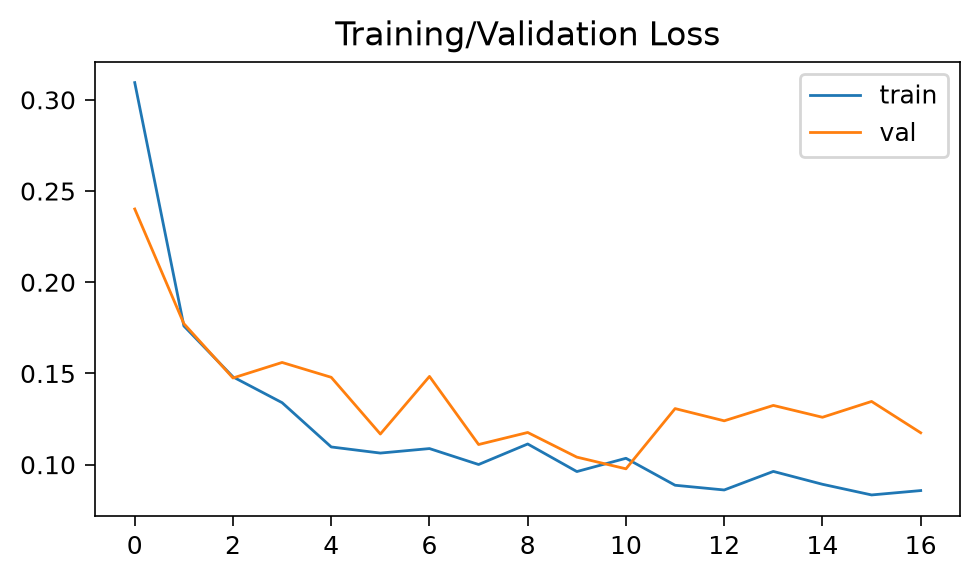

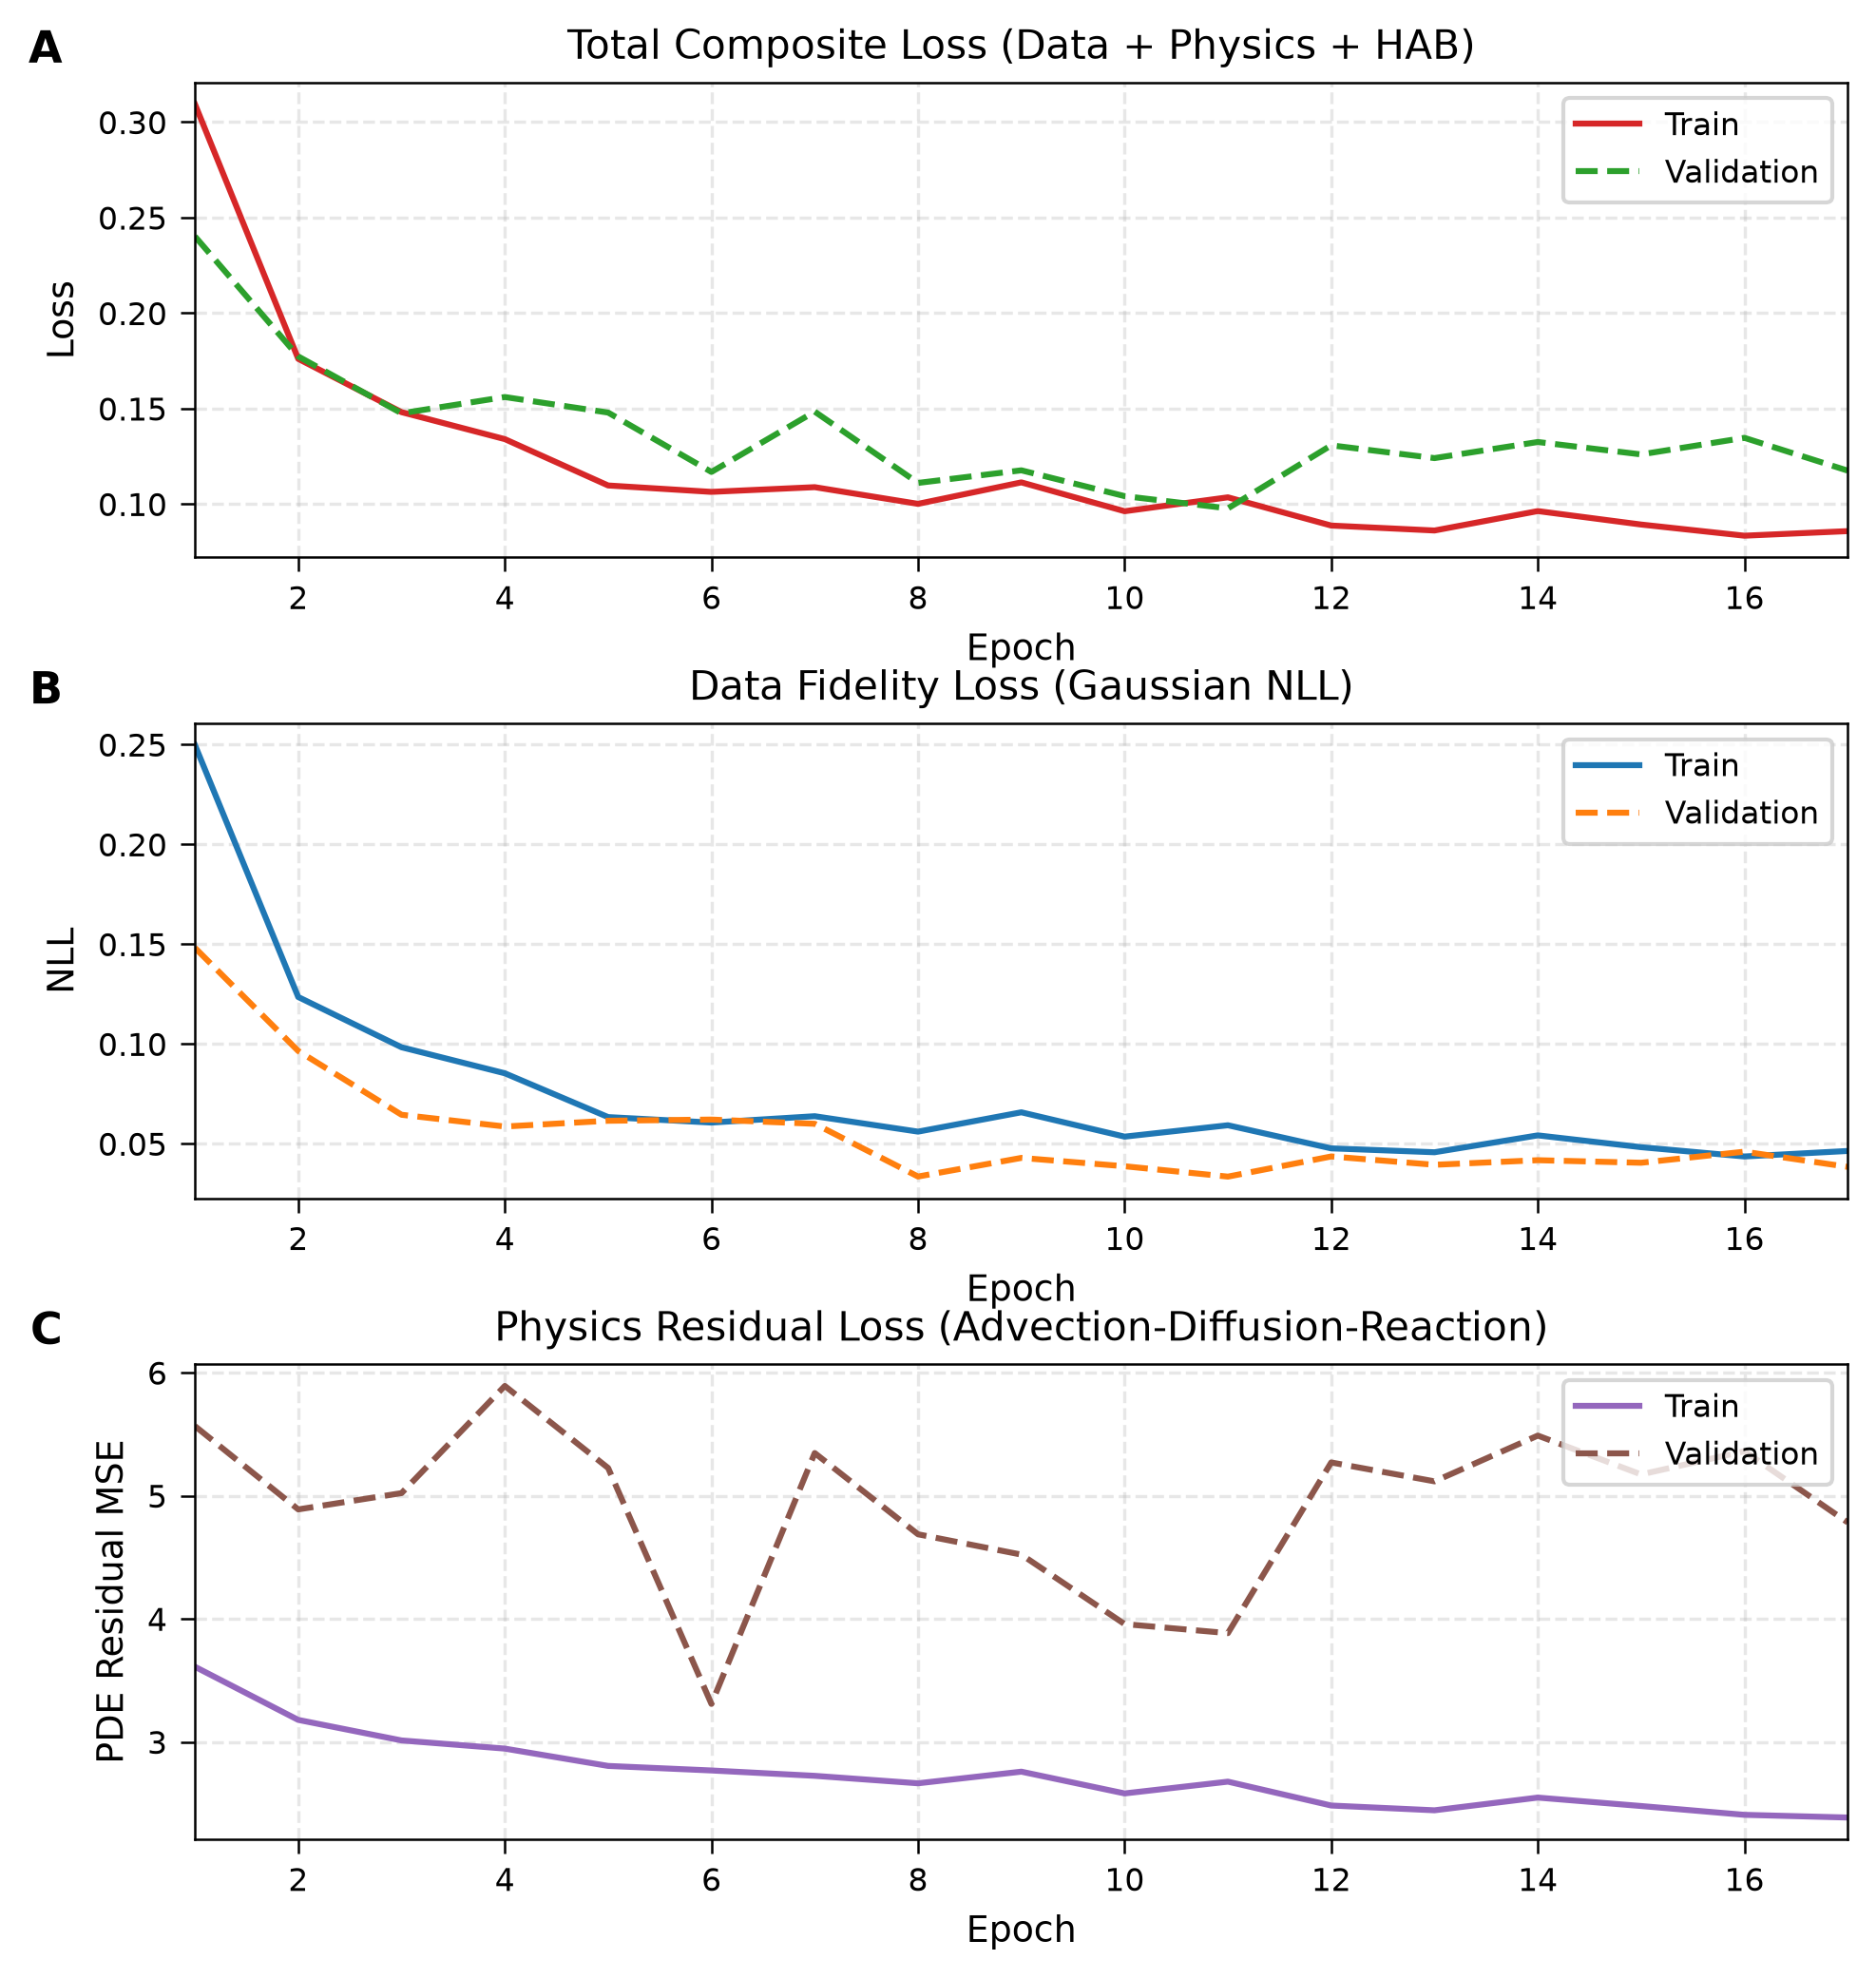

Saved detailed loss curves:
  Export_Figures\Fig_Loss_Complete.png
  Export_Figures\Fig_Loss_Complete.pdf
True
True
[ablation-a_baseline] epoch 01/15 train=0.3873 (data=0.3873, phys=0.0000) val=0.1667 (data=0.1667, phys=0.0000) r2=0.889
[ablation-a_baseline] epoch 02/15 train=0.1178 (data=0.1178, phys=0.0000) val=0.1398 (data=0.1398, phys=0.0000) r2=0.920
[ablation-a_baseline] epoch 03/15 train=0.1006 (data=0.1006, phys=0.0000) val=0.0744 (data=0.0744, phys=0.0000) r2=0.935
[ablation-a_baseline] epoch 04/15 train=0.0759 (data=0.0759, phys=0.0000) val=0.0712 (data=0.0712, phys=0.0000) r2=0.936
[ablation-a_baseline] epoch 05/15 train=0.0694 (data=0.0694, phys=0.0000) val=0.0861 (data=0.0861, phys=0.0000) r2=0.922
[ablation-a_baseline] epoch 06/15 train=0.0685 (data=0.0685, phys=0.0000) val=0.0753 (data=0.0753, phys=0.0000) r2=0.934
[ablation-a_baseline] epoch 07/15 train=0.0538 (data=0.0538, phys=0.0000) val=0.0744 (data=0.0744, phys=0.0000) r2=0.943
[ablation-a_baseline] epoch 08/15 tra

In [6]:
if __name__ == "__main__":
    import gc

    # =====================================================================
    # 0) Strict determinism
    # =====================================================================
    os.environ['PYTHONHASHSEED'] = '42'
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True, warn_only=True)

    # =====================================================================
    # 1) Load raw CSV
    # =====================================================================
    df = load_raw_dataframe(CSV_PATH)

    # =====================================================================
    # 2) Grid config — DEFAULT 24×24×12 (kept as original)
    # =====================================================================
    cfg = GridConfig(df)  # n_lat=24, n_lon=24, n_depth=12 (default)

    # =====================================================================
    # 3) Keep lightweight causal df BEFORE deleting heavy df
    # =====================================================================
    causal_cols = list(dict.fromkeys(["date", "month", "srhi"] + CAUSAL_VARS))
    causal_cols = [c for c in causal_cols if c in df.columns]
    df_causal = df[causal_cols].copy() if causal_cols else None

    # =====================================================================
    # 4) Build memmap tensor (disk-backed, minimal RAM)
    # =====================================================================
    tensor, dates = build_full_spatiotemporal_tensor(df, cfg)

    # Free heavy DataFrame immediately
    del df
    gc.collect()

    # =====================================================================
    # 5) Normalize on disk (chunk-based, minimal RAM)
    # =====================================================================
    tensor_norm, feat_mean, feat_std = normalize_tensor(
        tensor, out_path="grid_norm.dat", chunk_size=50
    )

    # =====================================================================
    # 6) Physics-derived fields (w, K fit easily in RAM)
    # =====================================================================
    w = diagnose_vertical_velocity(tensor, FEAT_IDX, cfg)
    K = diagnose_vertical_diffusivity(tensor, FEAT_IDX, cfg)

    # =====================================================================
    # 7) Sequences — LazySequenceArray wraps memmap
    # =====================================================================
    X, Y, seq_dates = make_sequences(tensor_norm, dates, cfg, TARGET_IDX)
    tr_idx, va_idx, te_idx = train_val_test_split_by_time(len(X))
    in_ch = tensor.shape[1]

    chl_mean_val = float(feat_mean[TARGET_IDX])
    chl_std_val = float(feat_std[TARGET_IDX])

    physics_data = {
        "raw_tensor": tensor,
        "w": w,
        "K": K,
        "chl_mean": chl_mean_val,
        "chl_std": chl_std_val,
    }

    print("Tensor:", tensor.shape, "Sequences:", X.shape)
    print("chl min/max:", tensor[:, FEAT_IDX["chl_bc"]].min(), tensor[:, FEAT_IDX["chl_bc"]].max())
    print("chl std:", tensor[:, FEAT_IDX["chl_bc"]].std())
    print("Temp raw min/max:", tensor[:, FEAT_IDX["temp"]].min(), tensor[:, FEAT_IDX["temp"]].max())

    # =====================================================================
    # 8) Causal graphs + GCN
    # =====================================================================
    if df_causal is not None:
        causal_graphs, causal_graphs_signed = compute_regime_causal_graphs(df_causal)
        del df_causal
        gc.collect()
    else:
        causal_graphs = {}
        causal_graphs_signed = {}

    gcn = SimpleGCNEncoder(n_nodes=len(CAUSAL_VARS), in_dim=8, hidden_dim=16, out_dim=16)
    active_graph = select_active_causal_graph(causal_graphs, 7, False)
    if active_graph is None:
        active_graph = np.zeros((len(CAUSAL_VARS), len(CAUSAL_VARS)), dtype=np.float32)
    _, graph_embed = gcn(active_graph)
    graph_embed = graph_embed.detach()

    # =====================================================================
    # 9) Datasets / loaders (seed immediately before)
    # =====================================================================
    set_global_seed(SEED)
    train_ds = HABSequenceDataset(
        X[tr_idx], {h: Y[h][tr_idx] for h in Y}, 0, 0, None, None, 0, 0, 0
    )
    val_ds = HABSequenceDataset(
        X[va_idx], {h: Y[h][va_idx] for h in Y}, 0, 0, None, None, 0, 0, 0
    )
    test_ds = HABSequenceDataset(
        X[te_idx], {h: Y[h][te_idx] for h in Y}, 0, 0, None, None, 0, 0, 0
    )
    train_loader = make_loader(train_ds, batch_size=6, shuffle=True, num_workers=0)
    val_loader = make_loader(val_ds, batch_size=4, shuffle=False, num_workers=0)
    test_loader = make_loader(test_ds, batch_size=4, shuffle=False, num_workers=0)

    # =====================================================================
    # 10) Skip benchmark for determinism
    # =====================================================================
    avg_step = 0.5  # manual estimate; benchmark_step_cost disabled to keep RNG clean

    N_TRIALS_HPO, HPO_EPOCHS, FINAL_EPOCHS = 20, 8, 30
    N_LOYO_YEARS = len(sorted(pd.unique(pd.to_datetime(seq_dates).year)))
    print_overall_runtime_plan(
        avg_step_seconds=avg_step,
        n_batches_train=len(train_loader),
        n_batches_val=len(val_loader),
        n_trials_hpo=N_TRIALS_HPO,
        hpo_epochs=HPO_EPOCHS,
        final_epochs=FINAL_EPOCHS,
        n_ablation_variants=4,
        ablation_epochs=15,
        n_loyo_years=N_LOYO_YEARS,
        loyo_epochs=10,
    )

    # =====================================================================
    # 11) Optuna HPO (seeded sampler for determinism)
    # =====================================================================
    set_global_seed(SEED)
    study = run_optuna_search(
        train_loader,
        val_loader,
        in_ch,
        cfg.n_depth,
        cfg,
        n_trials=N_TRIALS_HPO,
        physics_data=physics_data,
        hpo_epochs=HPO_EPOCHS,
        graph_embed=graph_embed,
    )
    best_params = (
        study.best_params
        if study is not None
        else {
            "hidden_ch": 32,
            "lr": 1e-3,
            "w_physics": 0.1,
            "fno_mode": 6,
            "mc_dropout": 0.15,
        }
    )

    # =====================================================================
    # 12) Train ONE final model (seed immediately before)
    # =====================================================================
    set_global_seed(SEED)
    final_model = PhysicsGuidedCausalHybridModel(
        in_ch,
        hidden_ch=best_params.get("hidden_ch", 32),
        n_depth=cfg.n_depth,
        fno_modes=(best_params.get("fno_mode", 6),) * 3,
        mc_dropout=best_params.get("mc_dropout", 0.15),
    )
    final_model.configure_physics(
        chl_mean_val, chl_std_val, FEAT_IDX["chl_bc"], enabled=True
    )

    final_model, history = train_model(
        final_model,
        train_loader,
        val_loader,
        cfg,
        epochs=FINAL_EPOCHS,
        lr=best_params.get("lr", 1e-3),
        w_physics=best_params.get("w_physics", 0.1),
        physics_data=physics_data,
        graph_embed=graph_embed,
        stage_label="final",
        benchmark_first=False,
    )
    plot_training_history(history)
    plot_all_losses(history, output_dir="Export_Figures", fname="Fig_Loss_Complete.png")

    # =====================================================================
    # 13) Extract denormalized predictions for test set
    # =====================================================================
    final_model.eval()
    all_mean_test = []
    with torch.no_grad():
        for x, y, idxs in test_loader:
            x = x.to(DEVICE)
            mean, _, _ = final_model(x, None, None)
            mean = mean.cpu().numpy()
            if mean.ndim == 5:          # (B, T, D, H, W) -> take last time step
                mean = mean[:, -1]
            all_mean_test.append(mean)
    pred_mean_test = np.concatenate(all_mean_test, axis=0)  # (N_test, D, H, W)
    pred_mean_phys = pred_mean_test * chl_std_val + chl_mean_val

    # Denormalize observed targets for test set (all horizons)
    Y_phys_te = {}
    for h in cfg.horizons:
        yh = Y[h][te_idx]
        Y_phys_te[h] = yh * chl_std_val + chl_mean_val

    # =====================================================================
    # 14) Ablation / Multi-horizon / Regime / LOYO
    # =====================================================================
    ablation_results = run_ablation_study(
        X, Y, tr_idx, va_idx, te_idx, in_ch, cfg.n_depth, cfg,
        physics_data=physics_data, graph_embed=graph_embed
    )
    mh_results = multi_horizon_evaluation(
        final_model, X, Y, te_idx, cfg, physics_data=physics_data
    )
    regime_results = cross_regime_evaluation(
        final_model, X, Y, seq_dates[te_idx], cfg, physics_data=physics_data
    )
    loyo_results = loyo_evaluation(
        lambda: PhysicsGuidedCausalHybridModel(in_ch, 32, cfg.n_depth),
        X,
        Y,
        seq_dates,
        cfg,
        epochs=10,
        physics_data=physics_data,
        graph_embed=graph_embed,
    )

    # =====================================================================
    # 15) Attribution & debug prints
    # =====================================================================
    attributions = process_attribution(
        final_model,
        X[te_idx][:8],
        Y[min(cfg.horizons)][te_idx][:8],
        FEAT_IDX,
        cfg,
    )
    print("Process attribution:", attributions)
    print("Multi-horizon:", mh_results)
    print("Cross-regime:", regime_results)
    print("LOYO:", loyo_results)

    y = Y[min(cfg.horizons)]
    print("Y min/max:", np.nanmin(y), np.nanmax(y))
    print("Y std:", np.nanstd(y))
    print("Unique values (sample):", np.unique(np.round(y.flatten(), 6))[:20])

    chl_idx = FEAT_IDX["chl_bc"]
    chl = tensor[:, chl_idx]
    print("chl_idx:", chl_idx)
    print("Chl tensor min/max:", np.nanmin(chl), np.nanmax(chl))
    print("Chl tensor std:", np.nanstd(chl))
    print("Nonzero fraction:", np.mean(chl != 0))
    for h in cfg.horizons:
        y = Y[h]
        print(h, y.shape, np.nanmin(y), np.nanmax(y), np.nanstd(y))

    # =====================================================================
    # 16) Publication figures (Fig 2–12)
    # =====================================================================
    print("\nGenerating publication figures...")
    generated_figures = generate_wr_publication_figures(
        model=final_model,
        X_test=X[te_idx],
        Y_test={h: Y[h][te_idx] for h in Y},
        seq_dates=seq_dates[te_idx],
        cfg=cfg,
        feat_idx=FEAT_IDX,
        physics_data=physics_data,
        causal_graphs=causal_graphs,
        causal_graphs_signed=causal_graphs_signed,   # NEW
        output_dir="Export_Figures",
        n_mc_samples=30,
        device=DEVICE,
        ablation_results=ablation_results,
        X_full=X,
        dates_full=seq_dates,
    )
    print("Standard figures saved.")

    # =====================================================================
    # 17) Figure 13: Point-specific + domain-averaged depth profiles
    # =====================================================================
    print("\nGenerating Figure 13: Depth Forecast Profiles...")
    plot_figure_13_depth_profiles(
        pred_mean=pred_mean_phys,          # SINGLE prediction array
        Y_phys=Y_phys_te,                  # {1: obs, 3: obs, 7: obs}
        cfg=cfg,
        dates=seq_dates[te_idx],
        sample_idx=len(te_idx) // 2,       # middle of test period
        lat_idx=cfg.n_lat // 2,
        lon_idx=cfg.n_lon // 2,
        output_dir="Export_Figures",
    )

    print("\nAll done.")